# Exploration des variables pour un modele de feu en fonction du temps

Objectif du notebook:
- clarifier les variables disponibles,
- identifier la variable cible liee au feu,
- explorer la dimension temporelle,
- preparer une premiere selection de variables candidates pour comparer plusieurs modeles de feu.

Cible imposee pour cette version:
- frequence de feu regionale.

Le but n'est pas encore d'entrainer un modele final, mais de comprendre quoi garder, quoi transformer et quoi exclure avant la phase de modelisation.

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

DATA_DIR = Path('.')
CSV_FILES = sorted(DATA_DIR.glob('*.csv'))
CSV_FILES

c:\Users\lenovo\anaconda3\envs\Ulrich\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.5)
  from scipy.stats import gaussian_kde


[WindowsPath('AnnTemp.csv'),
 WindowsPath('BBBootCISap.csv'),
 WindowsPath('cor_binned_all2annual-corrected.csv'),
 WindowsPath('FFBootCISap.csv'),
 WindowsPath('FSBootCISap.csv'),
 WindowsPath('Human.csv'),
 WindowsPath('Lake_fire_frequency_24nov2023.csv'),
 WindowsPath('M15_depths.csv'),
 WindowsPath('M15_names.csv'),
 WindowsPath('M15_spec.csv'),
 WindowsPath('O15_depths.csv'),
 WindowsPath('O15_names.csv'),
 WindowsPath('O15_spec.csv'),
 WindowsPath('Pollen50Reg.csv'),
 WindowsPath('Regional_pollen_depths.csv'),
 WindowsPath('Regional_pollen_names.csv'),
 WindowsPath('Regional_pollen_spec.csv')]

In [4]:
from pathlib import Path
import csv


def read_csv_robust(csv_path: Path) -> pd.DataFrame:
    """Read a CSV file with a couple of common delimiter/encoding fallbacks."""
    encodings = ['utf-8-sig', 'utf-8', 'latin1']
    separators = [None, ';', ',','\t']

    last_error = None
    for encoding in encodings:
        for sep in separators:
            try:
                return pd.read_csv(csv_path, encoding=encoding, sep=sep, engine='python')
            except Exception as exc:
                last_error = exc
    raise last_error


tables = {}
for csv_path in CSV_FILES:
    try:
        tables[csv_path.stem] = read_csv_robust(csv_path)
    except Exception as exc:
        print(f"[skip] {csv_path.name}: {exc}")

print(f"Fichiers CSV charges: {len(tables)}")
print(list(tables.keys()))


Fichiers CSV charges: 17
['AnnTemp', 'BBBootCISap', 'cor_binned_all2annual-corrected', 'FFBootCISap', 'FSBootCISap', 'Human', 'Lake_fire_frequency_24nov2023', 'M15_depths', 'M15_names', 'M15_spec', 'O15_depths', 'O15_names', 'O15_spec', 'Pollen50Reg', 'Regional_pollen_depths', 'Regional_pollen_names', 'Regional_pollen_spec']


# CLEAN_WINDOWS_CELL: remove rows/windows containing NaNs and rebuild loaders; if too few windows, impute NaNs instead
import numpy as np

def impute_array(arr):
    # Replace NaNs column-wise with median
    a = np.array(arr, dtype=float).copy()
    if a.ndim == 1:
        a = a.reshape(-1, 1)
    for j in range(a.shape[1]):
        col = a[:, j]
        mask = np.isnan(col)
        if mask.all():
            col[mask] = 0.0
        else:
            med = np.nanmedian(col)
            col[mask] = med
        a[:, j] = col
    return a

def clean_and_rebuild():
    global train_x, train_y, val_x, val_y, train_ds, val_ds, train_loader, val_loader
    # masks for rows without NaNs
    mask_train = np.ones(len(train_x), dtype=bool)
    mask_val = np.ones(len(val_x), dtype=bool)
    try:
        mask_train = ~np.isnan(train_x).any(axis=1) & ~np.isnan(train_y).reshape(-1)
        mask_val = ~np.isnan(val_x).any(axis=1) & ~np.isnan(val_y).reshape(-1)
    except Exception:
        pass

    removed_train = int((~mask_train).sum())
    removed_val = int((~mask_val).sum())
    print(f'Removing {removed_train} training rows and {removed_val} validation rows containing NaNs')

    tx = train_x[mask_train]
    ty = train_y[mask_train]
    vx = val_x[mask_val]
    vy = val_y[mask_val]

    # Build datasets to check window counts
    tmp_train_ds = SequenceWindowDataset(tx, ty)
    tmp_val_ds = SequenceWindowDataset(vx, vy)
    if len(tmp_train_ds) == 0 or len(tmp_val_ds) == 0:
        print('After removing NaN rows, no windows available. Applying column-wise median imputation instead.')
        tx = impute_array(train_x)
        ty = impute_array(train_y)
        vx = impute_array(val_x)
        vy = impute_array(val_y)
        # ensure float32 for torch
        tx = tx.astype(np.float32)
        ty = ty.astype(np.float32)
        vx = vx.astype(np.float32)
        vy = vy.astype(np.float32)
    else:
        tx = tx.astype(np.float32)
        ty = ty.astype(np.float32)
        vx = vx.astype(np.float32)
        vy = vy.astype(np.float32)

    # Assign back and recreate datasets/loaders
    train_x, train_y, val_x, val_y = tx, ty, vx, vy
    train_ds = SequenceWindowDataset(train_x, train_y)
    val_ds = SequenceWindowDataset(val_x, val_y)
    if len(train_ds) == 0 or len(val_ds) == 0:
        raise RuntimeError('Not enough data after cleaning/imputation to create windows. Check SEQ_INPUT_LEN and SEQ_HORIZON or the source data.')
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

    print(f'New shapes -> train_x: {train_x.shape}, train_y: {train_y.shape}, val_x: {val_x.shape}, val_y: {val_y.shape}')
    print(f'Fenêtres train: {len(train_ds)} | Fenêtres val: {len(val_ds)}')

# Execute cleaning
clean_and_rebuild()

# Re-load tables (ensure CSV_FILES and read_csv_robust are defined in earlier cells)
tables = {}
for csv_path in CSV_FILES:
    try:
        tables[csv_path.stem] = read_csv_robust(csv_path)
    except Exception as exc:
        print(f"[skip] {csv_path.name}: {exc}")

print(f"Fichiers CSV charges: {len(tables)}")
print(list(tables.keys()))

## 2. Nettoyage initial et gestion des valeurs manquantes

On identifie les doublons, les valeurs manquantes et les colonnes potentiellement incoherentes avant de construire les variables d'analyse.

## 3. Analyse de la variable cible liee au feu

On repere la ou les variables cibles candidates pour le feu, on examine leur distribution et on verifie si une version continue ou discrete est la plus pertinente.

In [6]:
from sklearn.linear_model import LinearRegression


def find_first_matching_column(df: pd.DataFrame, patterns):
    for pattern in patterns:
        matches = [col for col in df.columns if pattern.lower() in str(col).lower()]
        if matches:
            return matches[0]
    return None


def build_analysis_frame(tables):
    time_patterns = ['Age', 'age', 'Year', 'year', 'Time', 'time', 'Date', 'date', 'annee', 'Année']
    target_patterns = ['Mean', 'mean', 'freq', 'frequency', 'fire']

    if 'FFBootCISap' in tables:
        base_name = 'FFBootCISap'
    else:
        base_name = next(
            (
                name
                for name, df in tables.items()
                if find_first_matching_column(df, time_patterns) is not None
                and find_first_matching_column(df, target_patterns) is not None
            ),
            None,
        )

    if base_name is None:
        raise ValueError('No suitable time series table was found for the frequency analysis.')

    base_df = tables[base_name].copy().drop_duplicates().reset_index(drop=True)
    time_col = find_first_matching_column(base_df, time_patterns)
    target_col = find_first_matching_column(base_df, target_patterns)

    if time_col is None:
        raise ValueError(f'No time column found in {base_name}.')
    if target_col is None:
        raise ValueError(f'No target column found in {base_name}.')

    base_df[time_col] = pd.to_numeric(base_df[time_col], errors='coerce')
    base_df[target_col] = pd.to_numeric(base_df[target_col], errors='coerce')
    base_df = base_df.dropna(subset=[time_col, target_col]).sort_values(time_col).reset_index(drop=True)

    merged_frames = []
    for name, df in tables.items():
        df_work = df.copy().drop_duplicates().reset_index(drop=True)
        table_time_col = find_first_matching_column(df_work, time_patterns)
        if table_time_col is None:
            continue

        numeric_cols = df_work.select_dtypes(include=np.number).columns.tolist()
        if table_time_col in numeric_cols:
            numeric_cols.remove(table_time_col)

        if not numeric_cols:
            continue

        temp = df_work[[table_time_col] + numeric_cols].copy()
        temp[table_time_col] = pd.to_numeric(temp[table_time_col], errors='coerce')
        temp = temp.dropna(subset=[table_time_col]).drop_duplicates(subset=[table_time_col]).sort_values(table_time_col)

        if name == base_name:
            temp = temp.rename(columns={table_time_col: time_col})
        else:
            temp = temp.rename(columns={table_time_col: time_col, **{col: f'{name}__{col}' for col in numeric_cols}})

        merged_frames.append(temp)

    if not merged_frames:
        raise ValueError('Unable to build a merged analysis frame from the CSV files.')

    analysis_time = merged_frames[0]
    for temp in merged_frames[1:]:
        analysis_time = pd.merge(analysis_time, temp, on=time_col, how='outer')

    analysis_time = analysis_time.sort_values(time_col).reset_index(drop=True)
    numeric_analysis_cols = [
        col for col in analysis_time.columns
        if col != time_col and pd.api.types.is_numeric_dtype(analysis_time[col])
    ]
    if numeric_analysis_cols:
        analysis_time[numeric_analysis_cols] = (
            analysis_time[numeric_analysis_cols]
            .interpolate(limit_direction='both')
            .ffill()
            .bfill()
        )

    analysis_df = base_df.copy()
    return analysis_df, analysis_time, time_col, target_col, base_name


def coerce_time_to_numeric(series: pd.Series) -> pd.Series:
    numeric = pd.to_numeric(series, errors='coerce')
    if numeric.notna().any():
        return numeric.astype(float)

    parsed = pd.to_datetime(series, errors='coerce')
    if parsed.notna().any():
        return pd.Series(parsed.view('int64'), index=series.index, dtype='float64')

    return pd.Series(np.arange(len(series)), index=series.index, dtype='float64')


def run_linear_by_period(df, target_col, time_col_name, period_years, test_frac=0.2, min_samples=30):
    if time_col_name not in df.columns or target_col not in df.columns:
        raise ValueError(f'Missing required columns: {time_col_name} and/or {target_col}.')

    work = df[[time_col_name, target_col]].copy()
    work[target_col] = pd.to_numeric(work[target_col], errors='coerce')
    work['_time_numeric'] = coerce_time_to_numeric(work[time_col_name])
    work = work.dropna(subset=['_time_numeric', target_col]).sort_values('_time_numeric').reset_index(drop=True)

    if work.empty:
        return pd.DataFrame(), pd.DataFrame()

    period_offset = work['_time_numeric'].min()
    work['_period_id'] = np.floor((work['_time_numeric'] - period_offset) / float(period_years)).astype(int)

    metrics_rows = []
    preds_rows = []

    for period_id, period_df in work.groupby('_period_id', sort=True):
        period_df = period_df.sort_values('_time_numeric').reset_index(drop=True)
        if len(period_df) < min_samples:
            continue

        split_idx = int(round(len(period_df) * (1 - test_frac)))
        split_idx = max(1, min(split_idx, len(period_df) - 1))
        if split_idx <= 0 or split_idx >= len(period_df):
            continue

        train_df = period_df.iloc[:split_idx].copy()
        test_df = period_df.iloc[split_idx:].copy()
        if train_df.empty or test_df.empty:
            continue

        model = LinearRegression()
        model.fit(train_df[['_time_numeric']], train_df[target_col])
        predictions = model.predict(test_df[['_time_numeric']])

        metrics_rows.append({
            'period_years': period_years,
            'period_id': int(period_id),
            'n_train': len(train_df),
            'n_test': len(test_df),
            'MAE': mean_absolute_error(test_df[target_col], predictions),
            'RMSE': float(np.sqrt(mean_squared_error(test_df[target_col], predictions))),
            'R2': r2_score(test_df[target_col], predictions),
        })

        for time_value, truth_value, pred_value in zip(test_df[time_col_name], test_df[target_col], predictions):
            preds_rows.append({
                time_col_name: time_value,
                target_col: truth_value,
                'pred': pred_value,
                'period_years': period_years,
            })

    metrics_df = pd.DataFrame(metrics_rows)
    preds_df = pd.DataFrame(preds_rows)
    if not metrics_df.empty:
        metrics_df = metrics_df.sort_values(['period_years', 'period_id']).reset_index(drop=True)
    if not preds_df.empty:
        preds_df = preds_df.sort_values([time_col_name, 'period_years']).reset_index(drop=True)
    return metrics_df, preds_df


analysis_df, analysis_time, time_col, candidate_target, source_table_name = build_analysis_frame(tables)
print(f'Analysis table: {source_table_name}')
print(f'Time column: {time_col}')
print(f'Target column: {candidate_target}')
print(f'Analysis rows: {len(analysis_time)} | columns: {len(analysis_time.columns)}')

display(analysis_df.head(3))
display(analysis_time.head(3))


C:\Users\lenovo\AppData\Local\Temp\ipykernel_37692\597438578.py:75: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  analysis_time = pd.merge(analysis_time, temp, on=time_col, how='outer')
C:\Users\lenovo\AppData\Local\Temp\ipykernel_37692\597438578.py:75: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  analysis_time = pd.merge(analysis_time, temp, on=time_col, how='outer')
C:\Users\lenovo\AppData\Local\Temp\ipykernel_37692\597438578.py:75: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  analysis_time = pd.merge(analysis_time, temp, on=time_col, how='outer')
C:\Users\lenovo\AppData\Local\Temp\ipykernel_37692\597438578.py:75: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  analysis_time = pd.merge

Analysis table: FFBootCISap
Time column: Age
Target column: Mean
Analysis rows: 14263 | columns: 44


,Age,Mean,CI,Infe,Supe
0,-62,0.00397,0.9,0.002448,0.005514
1,-61,0.00397,0.9,0.002409,0.005545
2,-60,0.00397,0.9,0.002462,0.005588


,Age,AnnTemp__AnnTemp,AnnTemp__Unnamed: 2,AnnTemp__Unnamed: 3,AnnTemp__Unnamed: 4,BBBootCISap__Mean,BBBootCISap__CI,BBBootCISap__Infe,BBBootCISap__Supe,Mean,CI,Infe,Supe,FSBootCISap__Mean,FSBootCISap__CI,FSBootCISap__Infe,FSBootCISap__Supe,Human__human,M15_depths__depths,M15_depths__Depth,M15_depths__Age_OLD,O15_depths__depths,O15_depths__Depth,O15_depths__Age_OLD,Pollen50Reg__Abies,Pollen50Reg__Cupressaceae,Pollen50Reg__Larix,Pollen50Reg__Picea,Pollen50Reg__Pinus,Pollen50Reg__Alnus,Pollen50Reg__Betula,Pollen50Reg__Populus,Pollen50Reg__Quercus,Pollen50Reg__Salix,Pollen50Reg__Ulmus,Pollen50Reg__Ambrosia,Pollen50Reg__Artemisia,Pollen50Reg__Asteraceae,Pollen50Reg__Chenopodium,Pollen50Reg__Cyperaceae,Pollen50Reg__Poaceae,Pollen50Reg__Aquatics,Regional_pollen_depths__depths,Regional_pollen_depths__Depth
0,-62.0,-0.124983,NaN,NaN,NaN,0.023641,0.9,0.008164,0.038994,0.00397,0.9,0.002448,0.005514,0.688920,0.9,0.621528,0.754815,4.528384,570.000000,0.000000,-62.000000,390.000000,0.000000,-62.000000,1.418909,0.710853,1.248406,12.676318,56.014300,3.228284,11.661753,0.385694,1.374823,0.526785,0.294370,1.237380,1.713570,0.558144,0.990300,0.466820,1.461328,1.020428,1.000000,1.000000
1,-61.0,-0.124983,NaN,NaN,NaN,0.023339,0.9,0.009347,0.037836,0.00397,0.9,0.002409,0.005545,0.688738,0.9,0.620918,0.757118,4.528384,570.181818,0.181818,-60.963636,390.140845,0.140845,-60.957746,1.412361,0.714840,1.246453,12.636663,56.063914,3.230229,11.671256,0.386071,1.372305,0.525461,0.292816,1.241068,1.716516,0.557224,0.986683,0.468898,1.467987,1.017756,1.009615,1.961538
2,-60.0,-0.124983,NaN,NaN,NaN,0.023037,0.9,0.010253,0.036165,0.00397,0.9,0.002462,0.005588,0.688555,0.9,0.618522,0.761105,4.528384,570.363636,0.363636,-59.927273,390.281690,0.281690,-59.915493,1.405813,0.718826,1.244500,12.597008,56.113528,3.232174,11.680759,0.386449,1.369787,0.524138,0.291262,1.244755,1.719462,0.556304,0.983067,0.470976,1.474647,1.015085,1.019231,2.923077


## Synthese et prochaines etapes

A la fin de cette exploration, les points a retenir sont:
- la variable cible la plus pertinente,
- les colonnes de temps exploitables,
- les variables explicatives stables et informatives,
- les variables a exclure car trop redondantes, trop incompletes ou non causales.

La suite logique est de garder un petit ensemble de variables candidates, de tester plusieurs modeles de base, puis de passer a une validation temporelle plus rigoureuse.

## 12. Regression lineaire par periodes modulables pour l'intensite

Ici, on applique la meme logique a l'intensite du feu, avec un parametre de periode modulable.
Selon la nomenclature du projet, la table la plus proche de cette idee est souvent celle de la taille/severite (FS) ou de la biomasse brulee (BB).
L'objectif est de tester si une tendance temporelle lineaire existe aussi pour ce proxy.

Objectif cible: intensite du feu
Table d'analyse choisie: FSBootCISap


,Age,Mean,CI,Infe,Supe
0,-62,0.688920,0.9,0.621528,0.754815
1,-61,0.688738,0.9,0.620918,0.757118
2,-60,0.688555,0.9,0.618522,0.761105
3,-59,0.688328,0.9,0.620096,0.758085
4,-58,0.688100,0.9,0.617424,0.755407


,missing_count


Cible fixee (intensite): Mean


count    13063.000000
mean         0.668183
std          0.057625
min          0.569100
25%          0.627392
50%          0.651283
75%          0.694309
max          0.827715
Name: Mean, dtype: float64

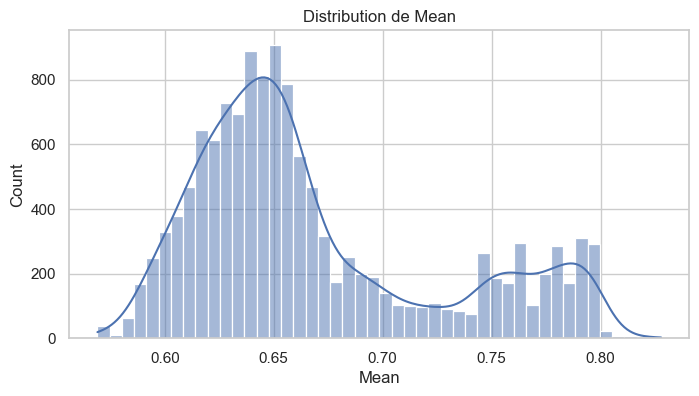

Colonne de temps candidate pour l'intensite: Age


,period_years,period_id,n_train,n_test,MAE,RMSE,R2
0,100,0,80,20,0.000643,0.000781,-0.662820
1,100,1,80,20,0.014623,0.014678,-51.728816
2,100,2,80,20,0.003581,0.003625,-35.688329
3,100,3,80,20,0.007932,0.007954,-29.990608
4,100,4,80,20,0.008184,0.008245,-250.304554
5,100,5,80,20,0.009259,0.009322,-77.678894
6,100,6,80,20,0.003857,0.003914,-590.099502
7,100,7,80,20,0.008896,0.009113,-14.261745
8,100,8,80,20,0.003318,0.003847,0.134389
9,100,9,80,20,0.009563,0.010859,-5.256082


Performance moyenne par taille de periode pour l'intensite:


,period_years,MAE,RMSE,R2
0,100,0.016144,0.016877,-150.080712
1,200,0.016513,0.018081,-22.325192
3,500,0.015909,0.018105,-13.932213
2,300,0.018636,0.020877,-11.359780
4,1000,0.019702,0.022043,-20.119289
5,1500,0.022229,0.026158,-3.617105
6,2000,0.030252,0.035662,-2.654896


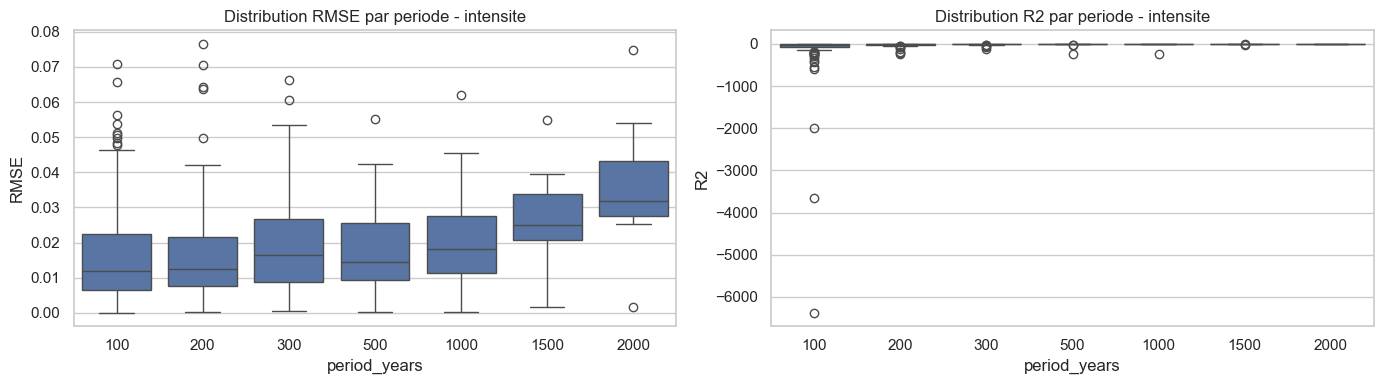

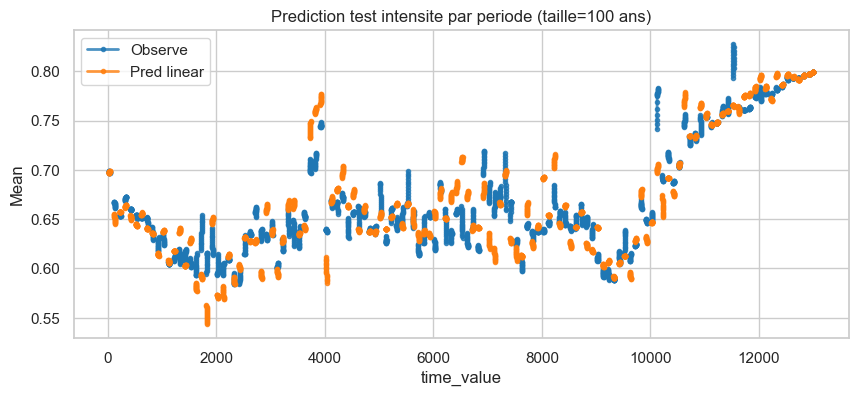

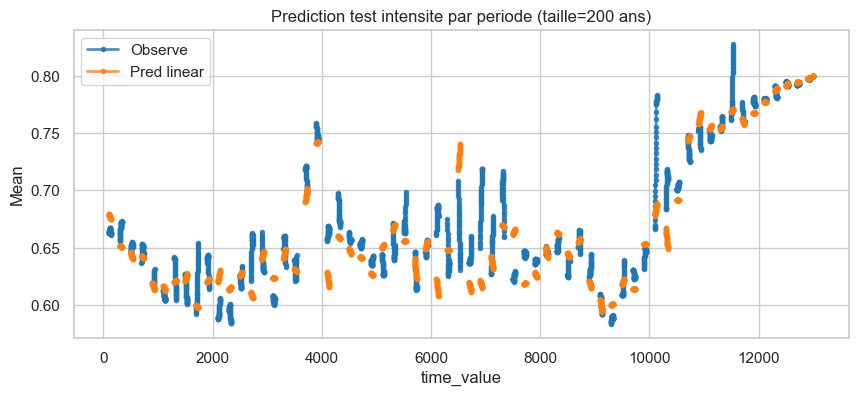

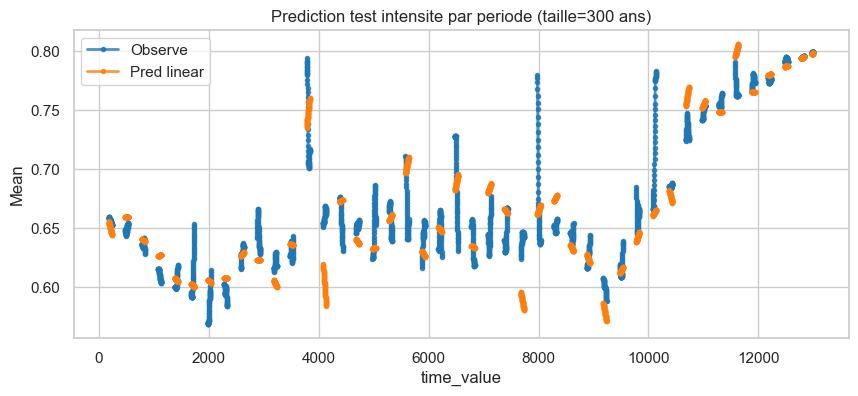

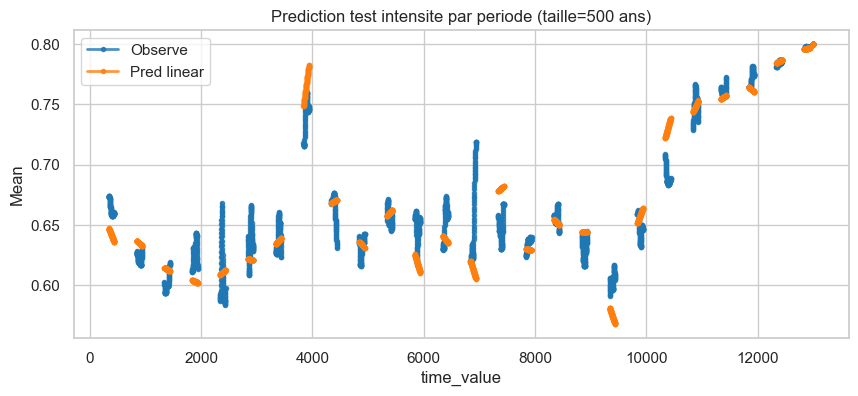

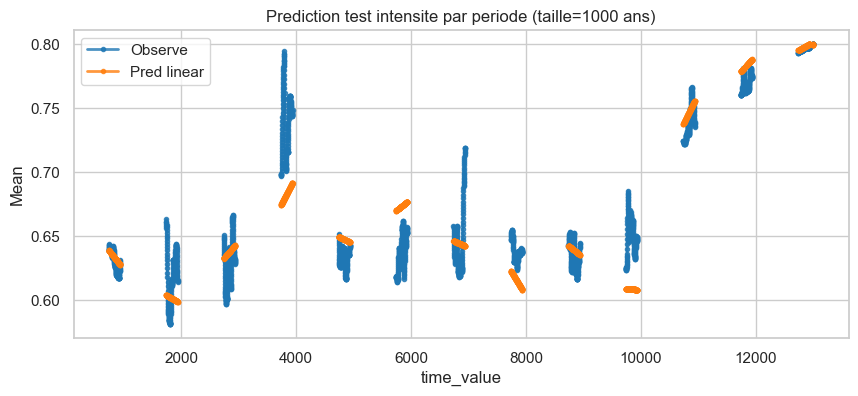

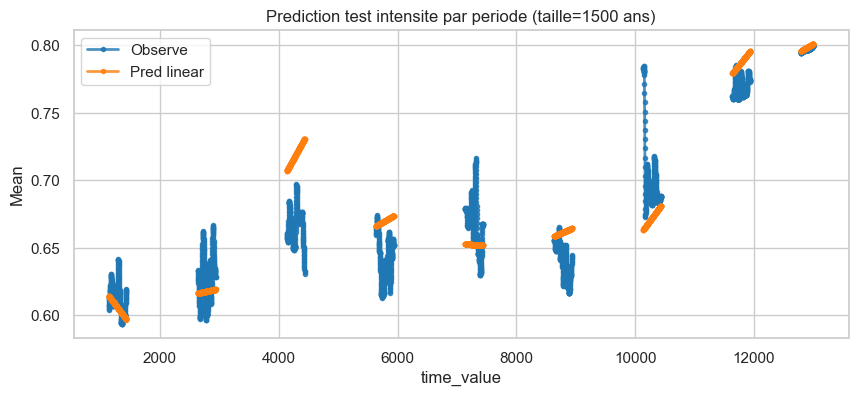

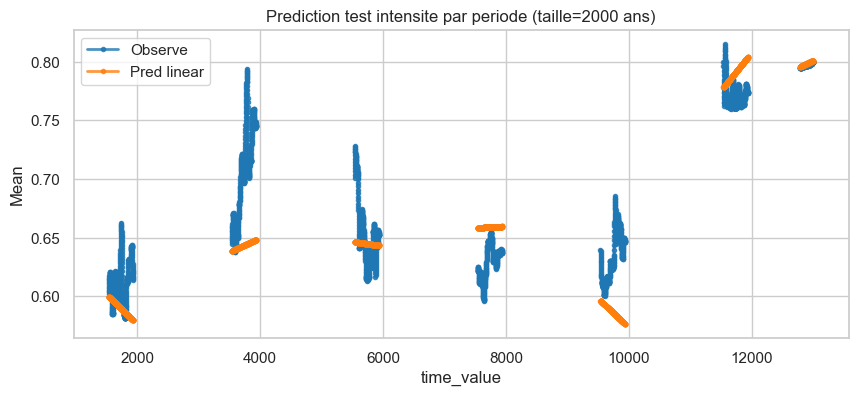

In [69]:
INTENSITY_OBJECTIVE = "intensite du feu"
INTENSITY_TABLE_PRIORITY = [
    'FSBootCISap',
    'BBBootCISap',
]
INTENSITY_COLUMN_PATTERNS = [
    'regfs',
    'regional_fire_size',
    'fire_size',
    'severity',
    'intensity',
    'bb',
    'biomass',
]
INTENSITY_BY_TABLE = {
    'FSBootCISap': 'Mean',
    'BBBootCISap': 'Mean',
}

# Choix explicite de la table la plus proche de l'intensite
intensity_name = next((name for name in INTENSITY_TABLE_PRIORITY if name in tables), None)
if intensity_name is None:
    intensity_name = next(
        (
            name for name, df in tables.items()
            if find_first_matching_column(df, INTENSITY_COLUMN_PATTERNS) is not None
        ),
        next(iter(tables)),
    )

intensity_df = tables[intensity_name].copy()
print(f"Objectif cible: {INTENSITY_OBJECTIVE}")
print(f"Table d'analyse choisie: {intensity_name}")
display(intensity_df.head())

intensity_df = intensity_df.drop_duplicates().reset_index(drop=True)
intensity_missing = intensity_df.isna().sum().sort_values(ascending=False)
display(intensity_missing[intensity_missing > 0].to_frame('missing_count'))

intensity_target = None
if intensity_name in INTENSITY_BY_TABLE and INTENSITY_BY_TABLE[intensity_name] in intensity_df.columns:
    intensity_target = INTENSITY_BY_TABLE[intensity_name]
else:
    intensity_target = find_first_matching_column(intensity_df, INTENSITY_COLUMN_PATTERNS)

if intensity_target is None:
    rescue = None
    for name, df in tables.items():
        mapped_col = INTENSITY_BY_TABLE.get(name)
        if mapped_col in df.columns:
            rescue = (name, mapped_col)
            break
        col = find_first_matching_column(df, INTENSITY_COLUMN_PATTERNS)
        if col is not None:
            rescue = (name, col)
            break

    if rescue is None:
        raise ValueError(
            "Aucune colonne compatible avec l'intensite n'a ete detectee automatiquement. "
            "Definis manuellement INTENSITY_BY_TABLE ou INTENSITY_COLUMN_PATTERNS."
        )

    intensity_name, intensity_target = rescue
    intensity_df = tables[intensity_name].drop_duplicates().reset_index(drop=True)
    print(f"Table recalee automatiquement vers: {intensity_name}")

print(f"Cible fixee (intensite): {intensity_target}")

if intensity_target is not None:
    intensity_series = intensity_df[intensity_target]
    if pd.api.types.is_numeric_dtype(intensity_series):
        display(intensity_series.describe())
        fig, ax = plt.subplots(figsize=(8, 4))
        sns.histplot(intensity_series.dropna(), kde=True, ax=ax)
        ax.set_title(f"Distribution de {intensity_target}")
        plt.show()
    else:
        display(intensity_series.value_counts(dropna=False).to_frame('count'))

intensity_time_col = find_first_matching_column(intensity_df, ['year', 'age', 'time', 'date', 'annee'])
print(f"Colonne de temps candidate pour l'intensite: {intensity_time_col}")

intensity_time = intensity_df.copy()
if intensity_time_col is not None:
    if np.issubdtype(intensity_time[intensity_time_col].dtype, np.number):
        intensity_time['time_value'] = pd.to_numeric(intensity_time[intensity_time_col], errors='coerce')
    else:
        parsed_time = pd.to_datetime(intensity_time[intensity_time_col], errors='coerce')
        intensity_time['time_value'] = parsed_time

if intensity_target is not None and intensity_time_col is not None and pd.api.types.is_numeric_dtype(intensity_time[intensity_target]):
    period_options_intensity = [100, 200, 300, 500, 1000, 1500, 2000]
    intensity_metrics_all = []
    intensity_preds_all = []
    plot_time_col_intensity = 'time_value' if 'time_value' in intensity_time.columns else intensity_time_col

    for p in period_options_intensity:
        metrics_p, preds_p = run_linear_by_period(
            intensity_time,
            target_col=intensity_target,
            time_col_name=plot_time_col_intensity,
            period_years=p,
            test_frac=0.2,
            min_samples=30,
        )
        if not metrics_p.empty:
            intensity_metrics_all.append(metrics_p)
        if not preds_p.empty:
            intensity_preds_all.append(preds_p)

    intensity_metrics_by_period = pd.concat(intensity_metrics_all, ignore_index=True) if intensity_metrics_all else pd.DataFrame()
    intensity_preds_by_period = pd.concat(intensity_preds_all, ignore_index=True) if intensity_preds_all else pd.DataFrame()

    if not intensity_metrics_by_period.empty:
        display(intensity_metrics_by_period.head(20))

        intensity_summary = (
            intensity_metrics_by_period.groupby('period_years')[['MAE', 'RMSE', 'R2']]
            .mean()
            .reset_index()
            .sort_values('RMSE')
        )
        print('Performance moyenne par taille de periode pour l\'intensite:')
        display(intensity_summary)

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        sns.boxplot(data=intensity_metrics_by_period, x='period_years', y='RMSE', ax=axes[0])
        axes[0].set_title('Distribution RMSE par periode - intensite')

        sns.boxplot(data=intensity_metrics_by_period, x='period_years', y='R2', ax=axes[1])
        axes[1].set_title('Distribution R2 par periode - intensite')
        plt.tight_layout()
        plt.show()

        if not intensity_preds_by_period.empty:
            def plot_broken_lines(ax, x, y, label=None, color=None, alpha=0.8, marker='-', linewidth=2, **kwargs):
                x_ser = pd.Series(x).reset_index(drop=True)
                y_ser = pd.Series(y).reset_index(drop=True)
                if len(x_ser) == 0:
                    return
                try:
                    if np.issubdtype(x_ser.dtype, np.datetime64):
                        x_num = x_ser.view('int64').astype(float)
                    else:
                        x_num = pd.to_numeric(x_ser, errors='coerce').values.astype(float)
                except Exception:
                    x_num = pd.to_numeric(x_ser, errors='coerce').values.astype(float)

                if len(x_num) <= 1 or np.all(np.isnan(x_num)):
                    ax.plot(x_ser, y_ser, label=label, color=color, alpha=alpha, marker=marker, linewidth=linewidth, **kwargs)
                    return

                diffs = np.diff(x_num)
                pos = diffs[~np.isnan(diffs) & (diffs > 0)]
                thresh = (np.median(pos) * 3) if len(pos) > 0 else 0

                segments = []
                start = 0
                for i, d in enumerate(diffs):
                    if thresh > 0 and d > thresh:
                        segments.append((start, i + 1))
                        start = i + 1
                segments.append((start, len(x_ser)))

                first = True
                for s, e in segments:
                    if s >= e:
                        continue
                    if first and label is not None:
                        ax.plot(x_ser.iloc[s:e], y_ser.iloc[s:e], label=label, color=color, alpha=alpha, marker=marker, linewidth=linewidth, **kwargs)
                        first = False
                    else:
                        ax.plot(x_ser.iloc[s:e], y_ser.iloc[s:e], color=color, alpha=alpha, marker=marker, linewidth=linewidth, **kwargs)

            for p in sorted(intensity_preds_by_period['period_years'].unique()):
                sub = intensity_preds_by_period[intensity_preds_by_period['period_years'] == p].sort_values(plot_time_col_intensity)
                fig, ax = plt.subplots(figsize=(10, 4))
                plot_broken_lines(ax, sub[plot_time_col_intensity], sub[intensity_target], label='Observe', color='tab:blue', alpha=0.8, marker='.', linewidth=2)
                plot_broken_lines(ax, sub[plot_time_col_intensity], sub['pred'], label='Pred linear', color='tab:orange', alpha=0.8, marker='.', linewidth=2)
                ax.set_title(f'Prediction test intensite par periode (taille={p} ans)')
                ax.set_xlabel(plot_time_col_intensity)
                ax.set_ylabel(intensity_target)
                ax.legend()
                plt.show()
    else:
        print('Aucune periode valide pour la regression lineaire de l\'intensite avec les parametres actuels.')
else:
    print('Impossible de lancer la regression lineaire de l\'intensite: cible ou temps non definis.')

## 13. Version avec split aleatoire pour la frequence et l'intensite

Cette version sert de point de comparaison avec la version chronologique.
Le split est aleatoire, avec une proportion de test fixe et une graine pour la reproductibilite.
On conserve la meme logique de preparation des variables et on retire les colonnes de fuite.

In [70]:
from sklearn.model_selection import train_test_split


def prepare_random_split_frame(df, target_col, time_col_name=None):
    work = df.dropna(subset=[target_col]).copy()

    leakage_patterns = ['ci', 'infe', 'supe', 'lower', 'upper', 'bound', 'interval']
    excluded_cols = {target_col}
    if time_col_name is not None:
        excluded_cols.add(time_col_name)

    excluded_cols.update(
        col for col in work.columns
        if any(pat in str(col).lower() for pat in leakage_patterns)
    )

    feature_cols = [col for col in work.columns if col not in excluded_cols]
    X = work[feature_cols]
    y = work[target_col]

    return work, X, y, excluded_cols



def run_random_split_benchmark(df, target_col, time_col_name=None, test_size=0.2, random_state=42):
    work, X, y, excluded_cols = prepare_random_split_frame(df, target_col, time_col_name=time_col_name)

    print('Colonnes exclues (fuite/structure):', sorted(excluded_cols))

    numeric_features = X.select_dtypes(include=np.number).columns.tolist()
    categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()
    print('Features numeriques retenues:', numeric_features)
    print('Features categoricielles retenues:', categorical_features)

    if len(work) < 20 or not (numeric_features or categorical_features):
        print('Pas assez de donnees ou de variables pour un benchmark aleatoire de base.')
        return pd.DataFrame()

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        shuffle=True,
    )

    try:
        encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_features),
            ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', encoder)]), categorical_features),
        ],
        remainder='drop',
    )

    models = {
        'DummyMean': DummyRegressor(strategy='mean'),
        'Ridge': Ridge(alpha=1.0),
        'RandomForest': RandomForestRegressor(n_estimators=200, random_state=random_state),
        'HistGradientBoosting': HistGradientBoostingRegressor(random_state=random_state),
    }

    results = []
    for model_name, model in models.items():
        pipe = Pipeline([('preprocess', preprocessor), ('model', model)])
        pipe.fit(X_train, y_train)
        predictions = pipe.predict(X_test)
        mse = mean_squared_error(y_test, predictions)
        results.append({
            'model': model_name,
            'MAE': mean_absolute_error(y_test, predictions),
            'RMSE': float(np.sqrt(mse)),
            'R2': r2_score(y_test, predictions),
        })

    return pd.DataFrame(results).sort_values('RMSE')


if candidate_target is not None and pd.api.types.is_numeric_dtype(analysis_time[candidate_target]):
    random_freq_results = run_random_split_benchmark(
        analysis_time,
        target_col=candidate_target,
        time_col_name=time_col,
        test_size=0.2,
        random_state=42,
    )

    if not random_freq_results.empty:
        print('Benchmark aleatoire - frequence de feu regionale')
        display(random_freq_results)
else:
    print('Benchmark aleatoire frequence impossible: cible non definie ou non numerique.')


if intensity_target is not None and pd.api.types.is_numeric_dtype(intensity_time[intensity_target]):
    random_intensity_results = run_random_split_benchmark(
        intensity_time,
        target_col=intensity_target,
        time_col_name=intensity_time_col,
        test_size=0.2,
        random_state=42,
    )

    if not random_intensity_results.empty:
        print('Benchmark aleatoire - intensite du feu')
        display(random_intensity_results)
else:
    print('Benchmark aleatoire intensite impossible: cible non definie ou non numerique.')

Colonnes exclues (fuite/structure): ['Age', 'BBBootCISap__CI', 'BBBootCISap__Infe', 'BBBootCISap__Mean', 'BBBootCISap__Supe', 'CI', 'FSBootCISap__CI', 'FSBootCISap__Infe', 'FSBootCISap__Mean', 'FSBootCISap__Supe', 'Infe', 'Mean', 'Supe']
Features numeriques retenues: ['AnnTemp__AnnTemp', 'AnnTemp__Unnamed: 2', 'AnnTemp__Unnamed: 3', 'AnnTemp__Unnamed: 4', 'Human__human', 'M15_depths__depths', 'M15_depths__Depth', 'M15_depths__Age_OLD', 'O15_depths__depths', 'O15_depths__Depth', 'O15_depths__Age_OLD', 'Pollen50Reg__Abies', 'Pollen50Reg__Cupressaceae', 'Pollen50Reg__Larix', 'Pollen50Reg__Picea', 'Pollen50Reg__Pinus', 'Pollen50Reg__Alnus', 'Pollen50Reg__Betula', 'Pollen50Reg__Populus', 'Pollen50Reg__Quercus', 'Pollen50Reg__Salix', 'Pollen50Reg__Ulmus', 'Pollen50Reg__Ambrosia', 'Pollen50Reg__Artemisia', 'Pollen50Reg__Asteraceae', 'Pollen50Reg__Chenopodium', 'Pollen50Reg__Cyperaceae', 'Pollen50Reg__Poaceae', 'Pollen50Reg__Aquatics', 'Regional_pollen_depths__depths', 'Regional_pollen_depths_

C:\Users\lenovo\anaconda3\envs\Ulrich\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['AnnTemp__Unnamed: 2' 'AnnTemp__Unnamed: 3' 'AnnTemp__Unnamed: 4']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\lenovo\anaconda3\envs\Ulrich\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['AnnTemp__Unnamed: 2' 'AnnTemp__Unnamed: 3' 'AnnTemp__Unnamed: 4']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\lenovo\anaconda3\envs\Ulrich\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['AnnTemp__Unnamed: 2' 'AnnTemp__Unnamed: 3' 'AnnTemp__Unnamed: 4']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\lenovo\anaconda3\envs\Ulrich\Lib\site-packages\sklearn\imp

Benchmark aleatoire - frequence de feu regionale


C:\Users\lenovo\anaconda3\envs\Ulrich\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: ['AnnTemp__Unnamed: 2' 'AnnTemp__Unnamed: 3' 'AnnTemp__Unnamed: 4']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


,model,MAE,RMSE,R2
2,RandomForest,0.000003,0.000014,0.999893
3,HistGradientBoosting,0.000123,0.000152,0.987506
1,Ridge,0.000161,0.000203,0.977637
0,DummyMean,0.001110,0.001356,-0.001198


Colonnes exclues (fuite/structure): ['Age', 'CI', 'Infe', 'Mean', 'Supe']
Features numeriques retenues: ['time_value']
Features categoricielles retenues: []
Benchmark aleatoire - intensite du feu


,model,MAE,RMSE,R2
2,RandomForest,0.000446,0.000748,9.998352e-01
3,HistGradientBoosting,0.007744,0.011792,9.590177e-01
1,Ridge,0.036026,0.044843,4.073760e-01
0,DummyMean,0.046828,0.058251,-1.009653e-07


## 14. Modèles séquentiels pour la fréquence

Cette section compare des modèles de séries temporelles (LSTM, Transformer, PatchTST) sur la fréquence de feu avec un split chronologique. 
On teste chaque modèle avec les mêmes données, les mêmes métriques d'erreur et des visuels de comparaison.

**Modèles testés:**
- **LSTM**: Réseau de neurones récurrents (baseline)
- **Transformer**: Encoder Transformer simple avec encodage positionnel
- **PatchTST**: Basé sur le papier ICLR 2023, approche par patchs avec Transformer

In [7]:
import math
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

torch.manual_seed(42)
np.random.seed(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Périphérique utilisé: {device}')

# Configuration pour les modèles séquentiels
SEQ_INPUT_LEN = 24      # Nombre de pas de temps en entrée
SEQ_HORIZON = 6         # Nombre de pas à prédire
VAL_FRACTION = 0.2      # Proportion de validation
BATCH_SIZE = 16         # Réduit pour plus de stabilité
EPOCHS = 12
LEARNING_RATE = 5e-5    # Très faible pour éviter l'instabilité

# Préparer les données pour la fréquence
freq_source_df = analysis_time.copy() if 'analysis_time' in globals() else None
if freq_source_df is None:
    raise RuntimeError('analysis_time non trouvé. Exécute les cellules précédentes.')

freq_target_col = candidate_target if 'candidate_target' in globals() and candidate_target is not None else None
if freq_target_col is None or freq_target_col not in freq_source_df.columns:
    raise RuntimeError('La cible de fréquence n\'a pas été identifiée.')

# Identifier la colonne de temps
if 'time_value' in freq_source_df.columns:
    freq_time_col = 'time_value'
elif 'time_col' in globals() and time_col in freq_source_df.columns:
    freq_time_col = time_col
else:
    freq_time_col = '__row_order__'
    freq_source_df = freq_source_df.reset_index(drop=True).rename(columns={'index': freq_time_col})

# Nettoyer et trier
freq_source_df = freq_source_df.drop_duplicates().copy()
freq_source_df = freq_source_df.sort_values(freq_time_col).reset_index(drop=True)

# Exclure les colonnes de fuite et les colonnes de type Unnamed
leakage_patterns = ['ci', 'infe', 'supe', 'lower', 'upper', 'bound', 'interval']
leakage_cols = [
    col for col in freq_source_df.columns
    if any(pat in str(col).lower() for pat in leakage_patterns)
]

# Sélectionner les variables numériques candidates (en excluant cible, temps et colonnes parasites)
numeric_candidates = freq_source_df.select_dtypes(include=np.number).columns.tolist()
freq_input_cols = [
    col for col in numeric_candidates
    if col not in {freq_target_col, freq_time_col}
    and col not in leakage_cols
    and 'unnamed' not in str(col).lower()
]

# Construire le dataframe de travail
freq_work = freq_source_df[[freq_time_col] + freq_input_cols + [freq_target_col]].copy()
for col in freq_input_cols + [freq_target_col]:
    freq_work[col] = pd.to_numeric(freq_work[col], errors='coerce')

# Remplacer explicitement les infinis par NaN avant l'imputation
freq_work = freq_work.replace([np.inf, -np.inf], np.nan)

# Retirer les colonnes sans aucune valeur exploitable ou sans variance
usable_input_cols = []
dropped_input_cols = []
for col in freq_input_cols:
    series = freq_work[col]
    non_na_count = int(series.notna().sum())
    distinct_count = int(series.nunique(dropna=True))
    if non_na_count == 0:
        dropped_input_cols.append(f'{col} (entièrement vide)')
        continue
    if distinct_count < 2:
        dropped_input_cols.append(f'{col} (constante ou quasi-constante)')
        continue
    usable_input_cols.append(col)

if dropped_input_cols:
    print(f'⚠ Colonnes exclues avant nettoyage: {dropped_input_cols[:12]}')
    if len(dropped_input_cols) > 12:
        print(f'   ... +{len(dropped_input_cols) - 12} autres')

freq_input_cols = usable_input_cols

# Imputer les valeurs manquantes uniquement sur les colonnes conservées
freq_work[freq_input_cols + [freq_target_col]] = (
    freq_work[freq_input_cols + [freq_target_col]]
    .interpolate(limit_direction='both')
    .ffill()
    .bfill()
)

# Retirer toute colonne d'entrée qui contient encore des NaN après imputation
remaining_nan_cols = [col for col in freq_input_cols if freq_work[col].isna().any()]
if remaining_nan_cols:
    print(f'⚠ Colonnes encore incomplètes après imputation: {remaining_nan_cols[:12]}')
    if len(remaining_nan_cols) > 12:
        print(f'   ... +{len(remaining_nan_cols) - 12} autres')
    freq_input_cols = [col for col in freq_input_cols if col not in remaining_nan_cols]
    freq_work = freq_work[[freq_time_col] + freq_input_cols + [freq_target_col]].copy()

# Supprimer les lignes encore incomplètes après imputation
freq_work = freq_work.dropna(subset=freq_input_cols + [freq_target_col]).reset_index(drop=True)

# Retirer les colonnes à variance quasi-zéro restantes (problématiques pour StandardScaler)
zero_var_cols = [col for col in freq_input_cols if freq_work[col].std() < 1e-8]
if zero_var_cols:
    print(f'⚠ Colonnes à variance zéro trouvées et exclues: {zero_var_cols}')
    freq_input_cols = [col for col in freq_input_cols if col not in zero_var_cols]
    freq_work = freq_work[[freq_time_col] + freq_input_cols + [freq_target_col]].copy()

print(f'Colonnes d\'entrée: {len(freq_input_cols)}')
print(f'Variable cible: {freq_target_col}')
print(f'Colonne de temps: {freq_time_col}')
print(f'Lignes totales: {len(freq_work)}')

Périphérique utilisé: cpu
Colonnes d'entrée: 28
Variable cible: Mean
Colonne de temps: Age
Lignes totales: 14263


In [5]:
# Diviser train/validation avec split chronologique
split_row = int(len(freq_work) * (1 - VAL_FRACTION))
train_frame = freq_work.iloc[:split_row].copy()
val_start = max(0, split_row - SEQ_INPUT_LEN - SEQ_HORIZON + 1)
val_frame = freq_work.iloc[val_start:].copy()

# Normaliser les données
input_scaler = StandardScaler()
target_scaler = StandardScaler()

train_x = input_scaler.fit_transform(train_frame[freq_input_cols])
train_y = target_scaler.fit_transform(train_frame[[freq_target_col]])
val_x = input_scaler.transform(val_frame[freq_input_cols])
val_y = target_scaler.transform(val_frame[[freq_target_col]])

print(f'Train: {len(train_x)} échantillons | Validation: {len(val_x)} échantillons')


class SequenceWindowDataset(Dataset):
    """Dataset pour fenêtres temporelles fixes."""
    def __init__(self, x_array, y_array, input_len=SEQ_INPUT_LEN, horizon=SEQ_HORIZON):
        self.x_array = x_array.astype(np.float32)
        self.y_array = y_array.astype(np.float32)
        self.input_len = input_len
        self.horizon = horizon

    def __len__(self):
        return max(0, len(self.x_array) - self.input_len - self.horizon + 1)

    def __getitem__(self, idx):
        x = self.x_array[idx : idx + self.input_len]
        y = self.y_array[idx + self.input_len : idx + self.input_len + self.horizon, 0]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


train_ds = SequenceWindowDataset(train_x, train_y)
val_ds = SequenceWindowDataset(val_x, val_y)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f'Fenêtres train: {len(train_ds)} | Fenêtres val: {len(val_ds)}')
print(f'Taille d\'entrée: ({SEQ_INPUT_LEN}, {len(freq_input_cols)}) | Horizon: {SEQ_HORIZON}')


NameError: name 'freq_work' is not defined

In [12]:
# === DIAGNOSTIC : Vérifier NaN/Inf dans les données ===
print('='*70)
print('DIAGNOSTIC DES DONNÉES'.center(70))
print('='*70)

# Vérifier les données brutes après imputation
print('\n1. DONNÉES BRUTES (après imputation):')
nan_count = freq_work[freq_input_cols + [freq_target_col]].isna().sum().sum()
inf_count = np.isinf(freq_work[freq_input_cols + [freq_target_col]]).sum().sum()
print(f'   NaN: {nan_count}, Inf: {inf_count}')
if nan_count > 0 or inf_count > 0:
    print(f'   ⚠ ALERTE: Données brutes contiennent NaN/Inf!')

# Vérifier les variances
print('\n2. VARIANCES:')
for col in freq_input_cols[:5]:  # Montrer les 5 premières
    var = freq_work[col].var()
    print(f'   {col}: var={var:.10f}')
print(f'   {freq_target_col}: var={freq_work[freq_target_col].var():.10f}')

if freq_work[freq_target_col].var() < 1e-10:
    print(f'   ⚠ ALERTE: Target a variance quasi-zéro!')

# Vérifier après scaling
print('\n3. DONNÉES NORMALISÉES:')
print(f'   Train X: min={train_x.min():.6f}, max={train_x.max():.6f}, mean={train_x.mean():.6f}, std={train_x.std():.6f}')
print(f'   Train Y: min={train_y.min():.6f}, max={train_y.max():.6f}, mean={train_y.mean():.6f}, std={train_y.std():.6f}')
print(f'   Val X: min={val_x.min():.6f}, max={val_x.max():.6f}, mean={val_x.mean():.6f}, std={val_x.std():.6f}')
print(f'   Val Y: min={val_y.min():.6f}, max={val_y.max():.6f}, mean={val_y.mean():.6f}, std={val_y.std():.6f}')

# Vérifier NaN/Inf après scaling
nan_count_scaled = (np.isnan(train_x).sum() + np.isnan(train_y).sum() + 
                    np.isnan(val_x).sum() + np.isnan(val_y).sum())
inf_count_scaled = (np.isinf(train_x).sum() + np.isinf(train_y).sum() + 
                    np.isinf(val_x).sum() + np.isinf(val_y).sum())
print(f'   NaN: {nan_count_scaled}, Inf: {inf_count_scaled}')
if nan_count_scaled > 0:
    print(f'   ⚠ ALERTE: Données normalisées contiennent NaN!')
if inf_count_scaled > 0:
    print(f'   ⚠ ALERTE: Données normalisées contiennent Inf!')

# Vérifier les scalers
print('\n4. SCALERS:')
print(f'   Input scaler means: min={input_scaler.mean_.min():.6f}, max={input_scaler.mean_.max():.6f}')
print(f'   Input scaler stds: min={input_scaler.scale_.min():.10f}, max={input_scaler.scale_.max():.10f}')
print(f'   Target scaler mean: {target_scaler.mean_[0]:.6f}')
print(f'   Target scaler std: {target_scaler.scale_[0]:.10f}')

if target_scaler.scale_[0] < 1e-10:
    print(f'   ⚠ ALERTE: Target scaler a scale quasi-zéro!')

print('\n✓ Diagnostic complété.')
print('='*70 + '\n')


                        DIAGNOSTIC DES DONNÉES                        

1. DONNÉES BRUTES (après imputation):
   NaN: 0, Inf: 0

2. VARIANCES:
   AnnTemp__AnnTemp: var=9.8978808195
   Human__human: var=22.8580705369
   M15_depths__depths: var=38441.7946377375
   M15_depths__Depth: var=38441.7946377375
   M15_depths__Age_OLD: var=11760549.8970469832
   Mean: var=0.0000019047

3. DONNÉES NORMALISÉES:
   Train X: min=-4.842031, max=3.883365, mean=0.000000, std=1.000000
   Train Y: min=-3.065333, max=1.644024, mean=-0.000000, std=1.000000
   Val X: min=-26.918520, max=2.063205, mean=-1.071999, std=3.870087
   Val Y: min=-6.548717, max=-2.964016, mean=-5.278291, std=0.876722
   NaN: 0, Inf: 0

4. SCALERS:
   Input scaler means: min=-0.273058, max=5192.338539
   Input scaler stds: min=0.2204405070, max=2994.3916498678
   Target scaler mean: 0.005519
   Target scaler std: 0.0005915891

✓ Diagnostic complété.



In [8]:
class PositionalEncoding(nn.Module):
    """Encodage positionnel pour Transformer."""
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        if d_model % 2 == 1:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])
        else:
            pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class LSTMForecaster(nn.Module):
    """Modèle LSTM pour prédiction de séries temporelles."""
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, out_len=SEQ_HORIZON):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_dim, out_len)

    def forward(self, x):
        output, (h_n, c_n) = self.lstm(x)
        return self.fc(output[:, -1, :])


class TransformerForecaster(nn.Module):
    """Transformer simple pour prédiction de séries temporelles."""
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=3, out_len=SEQ_HORIZON, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_encoding = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=4 * d_model,
            batch_first=True,
            dropout=dropout,
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, out_len)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_encoding(x)
        x = self.transformer_encoder(x)
        x = x.mean(dim=1)  # Agrégation globale
        return self.fc(x)


class PatchTSTLike(nn.Module):
    """Modèle PatchTST-like (inspiré du papier ICLR 2023)."""
    def __init__(self, input_dim, d_model=64, patch_size=4, nhead=4, num_layers=3, out_len=SEQ_HORIZON, dropout=0.1):
        super().__init__()
        self.patch_size = patch_size
        self.patch_proj = nn.Linear(patch_size * input_dim, d_model)
        self.pos_encoding = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=4 * d_model,
            batch_first=True,
            dropout=dropout,
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, out_len)

    def forward(self, x):
        batch_size, seq_len, num_features = x.shape
        patch_len = self.patch_size
        n_patches = seq_len // patch_len
        
        if n_patches < 1:
            # Fallback si la séquence est trop courte
            x = x.mean(dim=1)
            return self.fc(x)
        
        # Garder seulement les patchs complets
        x = x[:, : n_patches * patch_len, :]
        # Reshape en patchs: (batch_size, n_patches, patch_size * num_features)
        x = x.reshape(batch_size, n_patches, patch_len * num_features)
        x = self.patch_proj(x)
        x = self.pos_encoding(x)
        x = self.transformer_encoder(x)
        x = x.mean(dim=1)  # Agrégation globale
        return self.fc(x)


# Configuration des modèles à tester
MODEL_CONFIGS = [
    ('LSTM', {'input_dim': len(freq_input_cols), 'hidden_dim': 64, 'num_layers': 2}),
    ('Transformer', {'input_dim': len(freq_input_cols), 'd_model': 64, 'nhead': 4, 'num_layers': 3}),
    ('PatchTST', {'input_dim': len(freq_input_cols), 'd_model': 64, 'patch_size': 4, 'nhead': 4, 'num_layers': 3}),
]

print('Modèles configurés: LSTM, Transformer, PatchTST')


Modèles configurés: LSTM, Transformer, PatchTST


In [9]:
def train_epoch(model, train_loader, optimizer, criterion, device):
    """Entraîne le modèle pour une époque."""
    model.train()
    total_loss = 0.0
    valid_batches = 0
    
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        
        # Vérifier les NaN/Inf dans les entrées
        if torch.isnan(xb).any() or torch.isinf(xb).any():
            print(f'  ⚠ Batch avec NaN/Inf dans X, ignoré')
            continue
        if torch.isnan(yb).any() or torch.isinf(yb).any():
            print(f'  ⚠ Batch avec NaN/Inf dans Y, ignoré')
            continue
        
        optimizer.zero_grad()
        pred = model(xb)
        
        # Vérifier les NaN/Inf dans la prédiction
        if torch.isnan(pred).any() or torch.isinf(pred).any():
            print(f'  ⚠ Prédiction contient NaN/Inf, batch ignoré')
            continue
        
        loss = criterion(pred, yb)
        
        # Vérifier le loss
        if torch.isnan(loss) or torch.isinf(loss):
            print(f'  ⚠ Loss est NaN/Inf, batch ignoré')
            continue
        
        loss.backward()
        
        # Clipping des gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # Vérifier les gradients
        has_nan_grad = False
        for param in model.parameters():
            if param.grad is not None and (torch.isnan(param.grad).any() or torch.isinf(param.grad).any()):
                has_nan_grad = True
                break
        
        if has_nan_grad:
            print(f'  ⚠ Gradients contiennent NaN/Inf, batch ignoré')
            continue
        
        optimizer.step()
        
        total_loss += loss.item() * xb.size(0)
        valid_batches += 1
    
    if valid_batches == 0:
        return float('nan')
    
    return total_loss / (valid_batches * xb.size(0))


def validate(model, val_loader, criterion, device):
    """Évalue le modèle sur la validation."""
    model.eval()
    total_loss = 0.0
    valid_batches = 0
    
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            
            # Vérifier les inputs
            if torch.isnan(xb).any() or torch.isinf(xb).any():
                continue
            if torch.isnan(yb).any() or torch.isinf(yb).any():
                continue
            
            pred = model(xb)
            
            # Vérifier les prédictions
            if torch.isnan(pred).any() or torch.isinf(pred).any():
                continue
            
            loss = criterion(pred, yb)
            
            # Vérifier le loss
            if torch.isnan(loss) or torch.isinf(loss):
                continue
            
            total_loss += loss.item() * xb.size(0)
            valid_batches += 1
    
    if valid_batches == 0:
        return float('nan')
    
    return total_loss / (valid_batches * xb.size(0))


def fit_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LEARNING_RATE, device='cpu'):
    """Boucle d'entraînement complète."""
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    history = {'epoch': [], 'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    patience = 10
    patience_counter = 0
    
    for epoch in range(1, epochs + 1):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss = validate(model, val_loader, criterion, device)
        
        history['epoch'].append(epoch)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
        
        if epoch % 2 == 0 or epoch == 1:
            print(f'Epoch {epoch:2d}/{epochs} | Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f}')
        
        if patience_counter >= patience:
            print(f'  → Arrêt anticipé à l\'époque {epoch}')
            break
    
    return model, pd.DataFrame(history)


def predict_all(model, loader, device):
    """Récupère toutes les prédictions du modèle."""
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            pred = model(xb).cpu().numpy()
            preds.append(pred)
            trues.append(yb.numpy())
    
    preds = np.vstack(preds) if preds else np.empty((0, SEQ_HORIZON))
    trues = np.vstack(trues) if trues else np.empty((0, SEQ_HORIZON))
    return preds, trues


def inverse_normalize(values, scaler):
    """Dénormalise les valeurs."""
    flat = np.asarray(values).reshape(-1, 1)
    restored = scaler.inverse_transform(flat)
    return restored.reshape(np.asarray(values).shape)


def evaluate_model(preds, trues, model_name):
    """Calcule les métriques de performance."""
    if preds.size == 0 or trues.size == 0:
        return None, None
    
    preds_inv = inverse_normalize(preds, target_scaler)
    trues_inv = inverse_normalize(trues, target_scaler)
    
    # Vérifier et nettoyer les NaN/Inf après dénormalisation
    preds_inv = np.asarray(preds_inv, dtype=float)
    trues_inv = np.asarray(trues_inv, dtype=float)
    
    if not np.isfinite(preds_inv).any() or not np.isfinite(trues_inv).any():
        print(f'  ⚠ {model_name}: Prédictions ou vraies valeurs contiennent des NaN/Inf après dénormalisation')
        return None, None
    
    # Métriques sur le premier pas d'horizon
    first_pred = preds_inv[:, 0]
    first_true = trues_inv[:, 0]
    
    # Filtrer les NaN/Inf
    mask_h1 = np.isfinite(first_pred) & np.isfinite(first_true)
    if not mask_h1.any():
        print(f'  ⚠ {model_name}: Aucune valeur valide pour l\'horizon +1')
        return None, None
    
    first_pred_clean = first_pred[mask_h1]
    first_true_clean = first_true[mask_h1]
    
    # Métriques sur tous les horizons
    all_pred = preds_inv.reshape(-1)
    all_true = trues_inv.reshape(-1)
    mask_all = np.isfinite(all_pred) & np.isfinite(all_true)
    if not mask_all.any():
        print(f'  ⚠ {model_name}: Aucune valeur valide pour tous les horizons')
        return None, None
    
    all_pred_clean = all_pred[mask_all]
    all_true_clean = all_true[mask_all]
    
    metrics = {
        'Model': model_name,
        'MAE_h1': mean_absolute_error(first_true_clean, first_pred_clean),
        'RMSE_h1': float(np.sqrt(mean_squared_error(first_true_clean, first_pred_clean))),
        'R2_h1': r2_score(first_true_clean, first_pred_clean),
        'MAE_all': mean_absolute_error(all_true_clean, all_pred_clean),
        'RMSE_all': float(np.sqrt(mean_squared_error(all_true_clean, all_pred_clean))),
        'R2_all': r2_score(all_true_clean, all_pred_clean),
    }
    
    plot_data = {
        'time_idx': np.arange(len(first_pred_clean)),
        'truth_h1': first_true_clean,
        'pred_h1': first_pred_clean,
    }
    
    return metrics, plot_data

print('Fonctions d\'entraînement et d\'évaluation définies.')


Fonctions d'entraînement et d'évaluation définies.


In [18]:
# Entraîner tous les modèles
results_metrics = []
results_plots = {}
training_histories = {}
trained_models = {}

print(f'\n{"="*70}')
print(f'{"ENTRAÎNEMENT DES MODÈLES SÉQUENTIELS":^70}')
print(f'{"="*70}\n')

for model_name, model_kwargs in MODEL_CONFIGS:
    print(f'\n>>> {model_name.upper()}')
    print(f'{"-"*70}')
    
    # Créer le modèle
    if model_name == 'LSTM':
        model = LSTMForecaster(**model_kwargs)
    elif model_name == 'Transformer':
        model = TransformerForecaster(**model_kwargs)
    elif model_name == 'PatchTST':
        model = PatchTSTLike(**model_kwargs)
    
    # Entraîner
    model, history_df = fit_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LEARNING_RATE, device=device)
    training_histories[model_name] = history_df
    trained_models[model_name] = model
    
    # Prédire et évaluer
    preds, trues = predict_all(model, val_loader, device)
    metrics, plot_data = evaluate_model(preds, trues, model_name)
    
    if metrics is not None:
        results_metrics.append(metrics)
        results_plots[model_name] = plot_data
        print(f'\n  ✓ Performance (validation):')
        print(f'    MAE (h+1):  {metrics["MAE_h1"]:.4f}')
        print(f'    RMSE (h+1): {metrics["RMSE_h1"]:.4f}')
        print(f'    R² (h+1):   {metrics["R2_h1"]:.4f}')
    else:
        print(f'  ⚠ Aucune prédiction exploitable.')

# Résumé comparatif
if results_metrics:
    results_df = pd.DataFrame(results_metrics).sort_values('RMSE_h1')
    print(f'\n\n{"="*70}')
    print(f'{"RÉSUMÉ DES PERFORMANCES":^70}')
    print(f'{"="*70}\n')
    display(results_df)
else:
    print('⚠ Aucun résultat. Vérifier les données d\'entrée.')
    results_df = pd.DataFrame()



                 ENTRAÎNEMENT DES MODÈLES SÉQUENTIELS                 


>>> LSTM
----------------------------------------------------------------------
Epoch  1/12 | Train MSE: 1.731014 | Val MSE: 44.244366
Epoch  2/12 | Train MSE: 0.128800 | Val MSE: 41.412890
Epoch  4/12 | Train MSE: 0.014782 | Val MSE: 42.013864
Epoch  6/12 | Train MSE: 0.008744 | Val MSE: 42.058883
Epoch  8/12 | Train MSE: 0.006546 | Val MSE: 44.278526
Epoch 10/12 | Train MSE: 0.005276 | Val MSE: 45.964594
Epoch 12/12 | Train MSE: 0.003910 | Val MSE: 46.666948
  → Arrêt anticipé à l'époque 12

  ✓ Performance (validation):
    MAE (h+1):  0.0021
    RMSE (h+1): 0.0023
    R² (h+1):   -18.8381

>>> TRANSFORMER
----------------------------------------------------------------------
Epoch  1/12 | Train MSE: 0.881453 | Val MSE: 36.230354
Epoch  2/12 | Train MSE: 0.041060 | Val MSE: 36.482760
Epoch  4/12 | Train MSE: 0.011659 | Val MSE: 37.058884
Epoch  6/12 | Train MSE: 0.008520 | Val MSE: 39.643790
Epoch  8/12 | Trai

,Model,MAE_h1,RMSE_h1,R2_h1,MAE_all,RMSE_all,R2_all
2,PatchTST,0.001704,0.001831,-12.124725,0.001719,0.001849,-12.434202
0,LSTM,0.002055,0.002251,-18.838076,0.002068,0.002264,-19.139932
1,Transformer,0.002041,0.002265,-19.091189,0.002030,0.002256,-19.001690


In [15]:
# === TEST FORWARD PASS ===
print('='*70)
print('TEST FORWARD PASS'.center(70))
print('='*70 + '\n')

# Tester avec le premier batch
test_failed = False
for xb, yb in train_loader:
    xb = xb.to(device)
    yb = yb.to(device)
    
    print(f'Batch X: shape={xb.shape}, min={xb.min():.6f}, max={xb.max():.6f}')
    print(f'Batch Y: shape={yb.shape}, min={yb.min():.6f}, max={yb.max():.6f}')
    print(f'Batch X contains NaN: {torch.isnan(xb).any()}')
    print(f'Batch Y contains NaN: {torch.isnan(yb).any()}\n')
    
    # Tester chaque modèle
    for model_name, model_kwargs in MODEL_CONFIGS:
        print(f'Test: {model_name}')
        
        if model_name == 'LSTM':
            test_model = LSTMForecaster(**model_kwargs)
        elif model_name == 'Transformer':
            test_model = TransformerForecaster(**model_kwargs)
        elif model_name == 'PatchTST':
            test_model = PatchTSTLike(**model_kwargs)
        
        test_model = test_model.to(device)
        
        try:
            with torch.no_grad():
                pred = test_model(xb)
            print(f'  ✓ Forward pass OK: shape={pred.shape}')
            print(f'    Output: min={pred.min():.6f}, max={pred.max():.6f}')
            print(f'    Contains NaN: {torch.isnan(pred).any()}')
            
            # Test loss
            loss = nn.MSELoss()(pred, yb)
            print(f'    Loss: {loss.item():.6f}, Contains NaN: {torch.isnan(loss).any()}')
            
            if torch.isnan(pred).any() or torch.isnan(loss).any():
                test_failed = True
                print(f'  ⚠ ERREUR: Forward pass produit NaN!')
        except Exception as e:
            test_failed = True
            print(f'  ✗ Erreur: {e}')
        
        print()
    
    break  # Seulement tester le premier batch

if test_failed:
    print('\n⚠ Des erreurs ont été détectées lors du test forward pass')
else:
    print('\n✓ Tous les tests forward pass sont OK')

print('='*70 + '\n')


                          TEST FORWARD PASS                           

Batch X: shape=torch.Size([16, 24, 28]), min=-3.112630, max=2.301348
Batch Y: shape=torch.Size([16, 6]), min=-2.510103, max=1.568292
Batch X contains NaN: False
Batch Y contains NaN: False

Test: LSTM
  ✓ Forward pass OK: shape=torch.Size([16, 6])
    Output: min=-0.178494, max=0.116113
    Contains NaN: False
    Loss: 1.871155, Contains NaN: False

Test: Transformer
  ✓ Forward pass OK: shape=torch.Size([16, 6])
    Output: min=-0.856758, max=1.300190
    Contains NaN: False
    Loss: 2.362661, Contains NaN: False

Test: PatchTST
  ✓ Forward pass OK: shape=torch.Size([16, 6])
    Output: min=-1.095067, max=1.453683
    Contains NaN: False
    Loss: 2.140003, Contains NaN: False


✓ Tous les tests forward pass sont OK




                            VISUALISATIONS                            



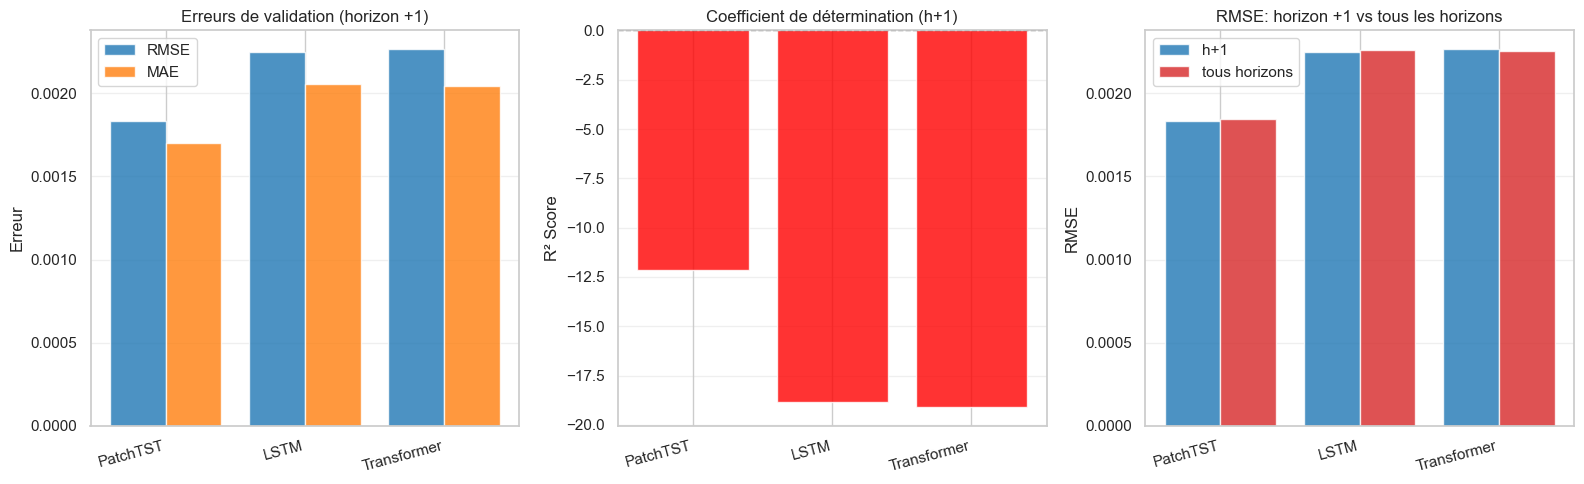

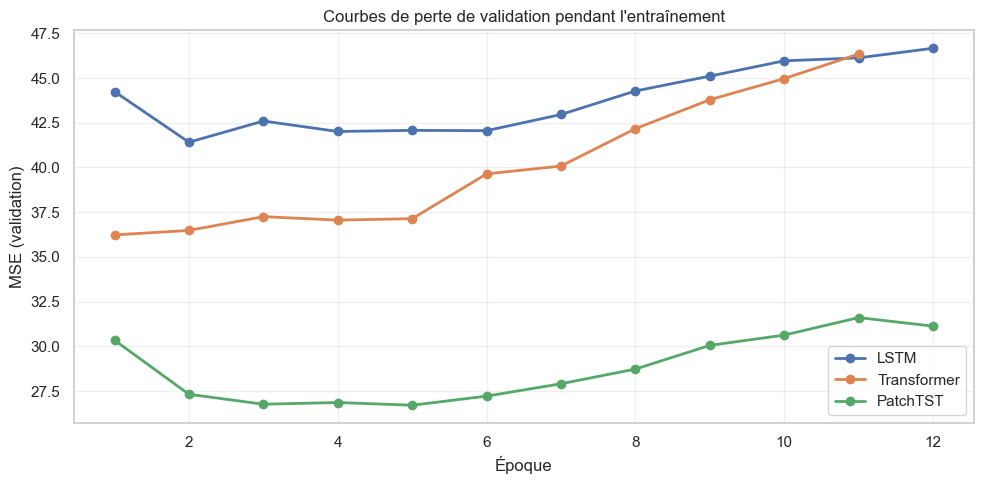

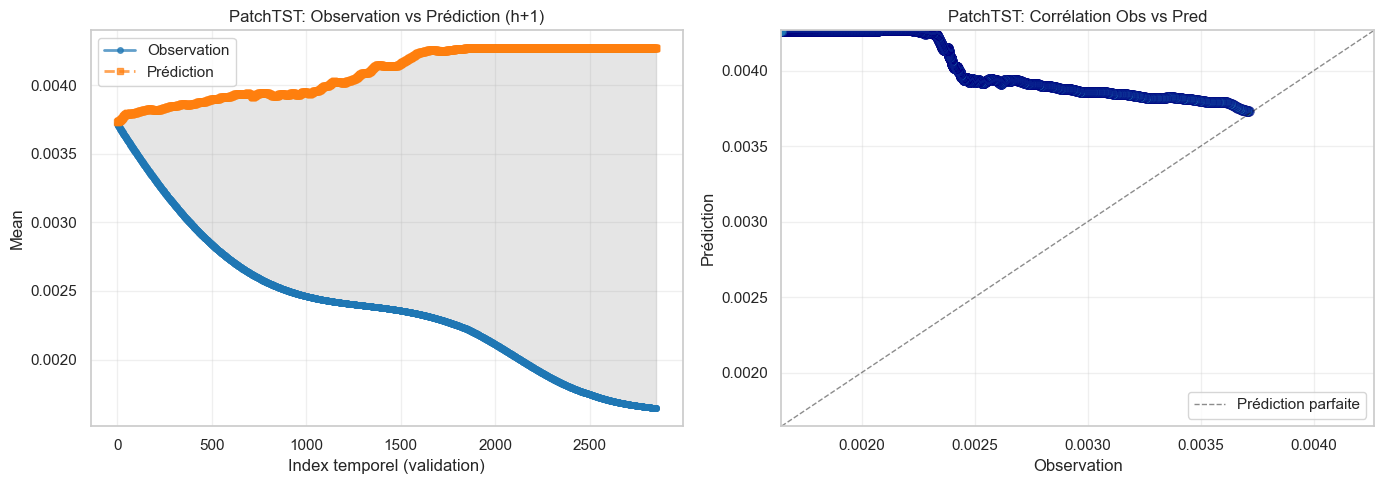

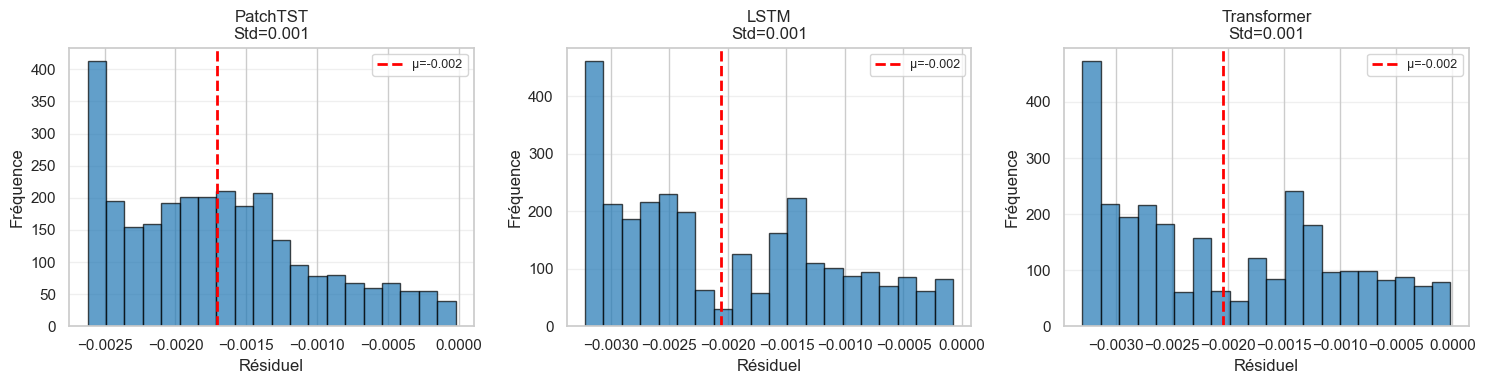


                      MEILLEUR MODÈLE: PatchTST                       
   Model   MAE_h1  RMSE_h1      R2_h1  MAE_all  RMSE_all     R2_all
PatchTST 0.001704 0.001831 -12.124725 0.001719  0.001849 -12.434202



In [19]:
# === VISUALISATION DES RÉSULTATS ===

if not results_df.empty:
    print(f'\n{"="*70}')
    print(f'{"VISUALISATIONS":^70}')
    print(f'{"="*70}\n')
    
    # Figure 1: Comparaison des erreurs et R²
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # Barre RMSE et MAE
    x_pos = np.arange(len(results_df))
    ax = axes[0]
    ax.bar(x_pos - 0.2, results_df['RMSE_h1'], width=0.4, label='RMSE', alpha=0.8, color='tab:blue')
    ax.bar(x_pos + 0.2, results_df['MAE_h1'], width=0.4, label='MAE', alpha=0.8, color='tab:orange')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
    ax.set_ylabel('Erreur')
    ax.set_title('Erreurs de validation (horizon +1)')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    # R² comparison
    ax = axes[1]
    colors = ['green' if r2 > 0 else 'red' for r2 in results_df['R2_h1']]
    ax.bar(x_pos, results_df['R2_h1'], alpha=0.8, color=colors)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
    ax.set_ylabel('R² Score')
    ax.set_title('Coefficient de détermination (h+1)')
    ax.grid(axis='y', alpha=0.3)
    
    # Comparaison multi-horizon
    ax = axes[2]
    ax.bar(x_pos - 0.2, results_df['RMSE_h1'], width=0.4, label='h+1', alpha=0.8, color='tab:blue')
    ax.bar(x_pos + 0.2, results_df['RMSE_all'], width=0.4, label='tous horizons', alpha=0.8, color='tab:red')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
    ax.set_ylabel('RMSE')
    ax.set_title('RMSE: horizon +1 vs tous les horizons')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Figure 2: Courbes d'entraînement
    fig, ax = plt.subplots(figsize=(10, 5))
    for model_name, history_df in training_histories.items():
        if not history_df.empty:
            ax.plot(history_df['epoch'], history_df['val_loss'], marker='o', label=model_name, linewidth=2, markersize=6)
    ax.set_xlabel('Époque')
    ax.set_ylabel('MSE (validation)')
    ax.set_title('Courbes de perte de validation pendant l\'entraînement')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Figure 3: Prédictions vs Observations (meilleur modèle)
    best_model_name = results_df.iloc[0]['Model']
    best_plot_data = results_plots[best_model_name]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Série temporelle complète
    ax = axes[0]
    ax.plot(best_plot_data['time_idx'], best_plot_data['truth_h1'], 'o-', 
            label='Observation', color='tab:blue', alpha=0.7, linewidth=2, markersize=4)
    ax.plot(best_plot_data['time_idx'], best_plot_data['pred_h1'], 's--', 
            label='Prédiction', color='tab:orange', alpha=0.7, linewidth=2, markersize=4)
    ax.fill_between(best_plot_data['time_idx'], best_plot_data['truth_h1'], 
                     best_plot_data['pred_h1'], alpha=0.2, color='gray')
    ax.set_xlabel('Index temporel (validation)')
    ax.set_ylabel(freq_target_col)
    ax.set_title(f'{best_model_name}: Observation vs Prédiction (h+1)')
    ax.legend()
    ax.grid(alpha=0.3)
    
    # Scatter plot: corrélation
    ax = axes[1]
    ax.scatter(best_plot_data['truth_h1'], best_plot_data['pred_h1'], 
               alpha=0.6, s=50, color='tab:blue', edgecolors='navy', linewidth=0.5)
    
    # Ligne de référence parfaite
    lims = [
        np.min([best_plot_data['truth_h1'].min(), best_plot_data['pred_h1'].min()]),
        np.max([best_plot_data['truth_h1'].max(), best_plot_data['pred_h1'].max()]),
    ]
    ax.plot(lims, lims, 'k--', alpha=0.5, linewidth=1, label='Prédiction parfaite')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel('Observation')
    ax.set_ylabel('Prédiction')
    ax.set_title(f'{best_model_name}: Corrélation Obs vs Pred')
    ax.legend()
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Figure 4: Distribution des résidus
    fig, axes = plt.subplots(1, len(results_df), figsize=(15, 4))
    if len(results_df) == 1:
        axes = [axes]
    
    for idx, model_name in enumerate(results_df['Model']):
        if model_name in results_plots:
            plot_data = results_plots[model_name]
            residuals = plot_data['truth_h1'] - plot_data['pred_h1']
            ax = axes[idx]
            ax.hist(residuals, bins=20, alpha=0.7, color='tab:blue', edgecolor='black')
            ax.axvline(x=residuals.mean(), color='red', linestyle='--', linewidth=2, 
                      label=f'μ={residuals.mean():.3f}')
            ax.set_xlabel('Résiduel')
            ax.set_ylabel('Fréquence')
            ax.set_title(f'{model_name}\nStd={residuals.std():.3f}')
            ax.legend(fontsize=9)
            ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Résumé final
    print(f'\n{"="*70}')
    print(f'{"MEILLEUR MODÈLE: " + best_model_name:^70}')
    print(f'{"="*70}')
    print(results_df[results_df['Model'] == best_model_name].to_string(index=False))
    print(f'{"="*70}\n')
    
else:
    print('⚠ Aucun résultat de modèle séquentiel. Vérifier les données d\'entrée et les configurations.')


## 15. Modèles séquentiels pour l'intensité

Cette section reproduit la logique de la section 14, mais appliquée à l'intensité du feu. On conserve les mêmes familles de modèles séquentiels et la même logique de split chronologique, en adaptant la préparation des données à la table d'intensité.

C:\Users\lenovo\AppData\Local\Temp\ipykernel_26264\791891505.py:106: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  intensity_analysis = pd.merge(intensity_analysis, temp, on=time_col, how='outer')
C:\Users\lenovo\AppData\Local\Temp\ipykernel_26264\791891505.py:106: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  intensity_analysis = pd.merge(intensity_analysis, temp, on=time_col, how='outer')
C:\Users\lenovo\AppData\Local\Temp\ipykernel_26264\791891505.py:106: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  intensity_analysis = pd.merge(intensity_analysis, temp, on=time_col, how='outer')
C:\Users\lenovo\AppData\Local\Temp\ipykernel_26264\791891505.py:106: UserWarning: You are merging on int and float columns where the float values are not equal to their int represen

⚠ Colonnes intensité exclues avant nettoyage: ['AnnTemp__Unnamed: 2 (vide)', 'AnnTemp__Unnamed: 3 (vide)', 'AnnTemp__Unnamed: 4 (vide)']
Table d'intensité choisie: FSBootCISap
Colonne de temps: Age
Variable cible: Mean
Colonnes d'entrée: 28
Lignes totales: 14263
Train: 11410 échantillons | Validation: 2882 échantillons
NaN train_x: 0 | NaN val_x: 0
Fenêtres train: 11381 | Fenêtres val: 2853
Taille d'entrée: (24, 28) | Horizon: 6

                 ENTRAÎNEMENT DES MODÈLES D'INTENSITÉ                 


>>> LSTM
----------------------------------------------------------------------
Epoch  1/12 | Train MSE: 2.558752 | Val MSE: 48.889559
Epoch  2/12 | Train MSE: 1.367580 | Val MSE: 48.430675
Epoch  4/12 | Train MSE: 0.857781 | Val MSE: 47.348561
Epoch  6/12 | Train MSE: 0.722594 | Val MSE: 46.125651
Epoch  8/12 | Train MSE: 0.628118 | Val MSE: 46.792982
Epoch 10/12 | Train MSE: 0.545636 | Val MSE: 47.733431
Epoch 12/12 | Train MSE: 0.482311 | Val MSE: 46.408694

  ✓ Performance (validation

,Model,MAE_h1,RMSE_h1,R2_h1,MAE_all,RMSE_all,R2_all
0,LSTM,0.111638,0.121802,-15.887579,0.113218,0.123295,-16.333723
2,PatchTST,0.121528,0.131935,-18.814413,0.120019,0.130422,-18.395552
1,Transformer,0.127434,0.135540,-19.911948,0.122181,0.129597,-18.151014


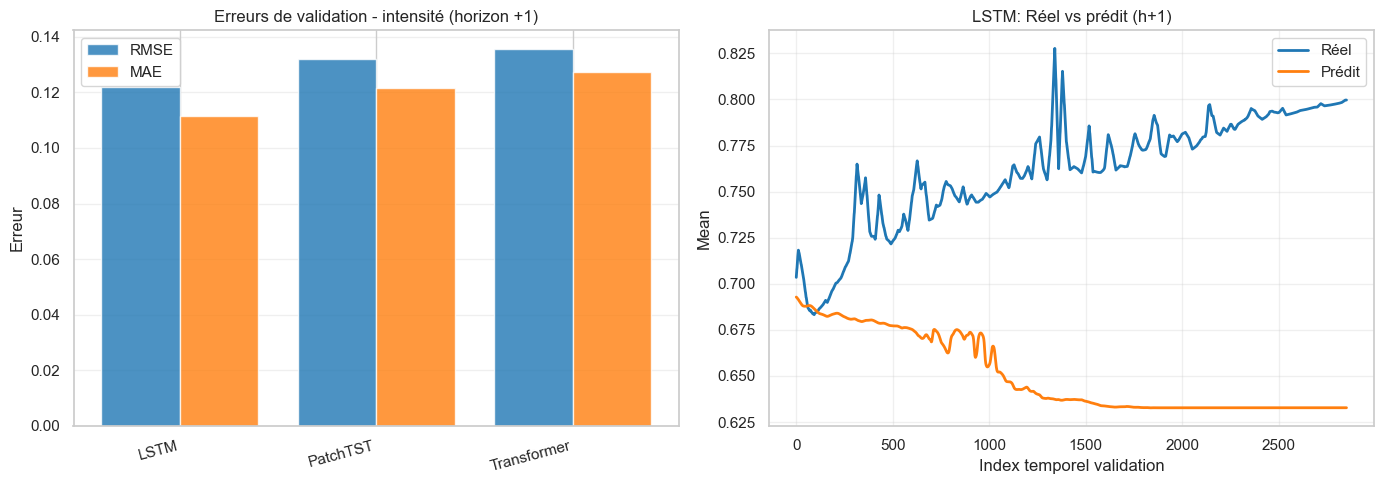


                     MEILLEUR MODÈLE D'INTENSITÉ                      
Model   MAE_h1  RMSE_h1      R2_h1  MAE_all  RMSE_all     R2_all
 LSTM 0.111638 0.121802 -15.887579 0.113218  0.123295 -16.333723



In [82]:
import math
import torch
from torch.utils.data import DataLoader, Dataset

# Cette cellule suppose que les cellules d'import et les définitions des modèles
# ont déjà été exécutées dans le notebook.

# Paramètres propres à la section intensité
device = 'cuda' if torch.cuda.is_available() else 'cpu'
SEQ_INPUT_LEN = 24
SEQ_HORIZON = 6
VAL_FRACTION = 0.2
BATCH_SIZE = 16
EPOCHS = 12
LEARNING_RATE = 5e-5


class SequenceWindowDataset(Dataset):
    """Dataset pour fenêtres temporelles fixes."""
    def __init__(self, x_array, y_array, input_len=SEQ_INPUT_LEN, horizon=SEQ_HORIZON):
        self.x_array = x_array.astype(np.float32)
        self.y_array = y_array.astype(np.float32)
        self.input_len = input_len
        self.horizon = horizon

    def __len__(self):
        return max(0, len(self.x_array) - self.input_len - self.horizon + 1)

    def __getitem__(self, idx):
        x = self.x_array[idx : idx + self.input_len]
        y = self.y_array[idx + self.input_len : idx + self.input_len + self.horizon, 0]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


def local_find_first_matching_column(df, patterns):
    for pattern in patterns:
        matches = [col for col in df.columns if pattern.lower() in str(col).lower()]
        if matches:
            return matches[0]
    return None


def build_intensity_frame_from_tables(tables):
    intensity_table_priority = ['FSBootCISap', 'BBBootCISap']
    time_patterns = ['Age', 'age', 'Year', 'year', 'Time', 'time', 'Date', 'date', 'annee', 'Année']
    target_patterns = ['Mean', 'mean', 'freq', 'frequency', 'fire', 'intensity', 'severity', 'size', 'biomass']

    if 'FSBootCISap' in tables:
        base_name = 'FSBootCISap'
    elif 'BBBootCISap' in tables:
        base_name = 'BBBootCISap'
    else:
        base_name = next(
            (
                name
                for name, df in tables.items()
                if local_find_first_matching_column(df, time_patterns) is not None
                and local_find_first_matching_column(df, target_patterns) is not None
            ),
            None,
        )
    if base_name is None:
        raise ValueError('Aucune table d\'intensité exploitable n\'a été trouvée.')

    base_df = tables[base_name].copy().drop_duplicates().reset_index(drop=True)
    time_col = local_find_first_matching_column(base_df, time_patterns)
    target_col = local_find_first_matching_column(base_df, target_patterns)
    if time_col is None:
        raise ValueError(f'Aucune colonne de temps trouvée dans {base_name}.')
    if target_col is None:
        raise ValueError(f'Aucune colonne cible trouvée dans {base_name}.')

    base_df[time_col] = pd.to_numeric(base_df[time_col], errors='coerce')
    base_df[target_col] = pd.to_numeric(base_df[target_col], errors='coerce')
    base_df = base_df.dropna(subset=[time_col, target_col]).sort_values(time_col).reset_index(drop=True)

    merged_frames = []
    for name, df in tables.items():
        df_work = df.copy().drop_duplicates().reset_index(drop=True)
        table_time_col = local_find_first_matching_column(df_work, time_patterns)
        if table_time_col is None:
            continue

        numeric_cols = df_work.select_dtypes(include=np.number).columns.tolist()
        if table_time_col in numeric_cols:
            numeric_cols.remove(table_time_col)
        if not numeric_cols:
            continue

        temp = df_work[[table_time_col] + numeric_cols].copy()
        temp[table_time_col] = pd.to_numeric(temp[table_time_col], errors='coerce')
        temp = temp.dropna(subset=[table_time_col]).drop_duplicates(subset=[table_time_col]).sort_values(table_time_col)

        if name == base_name:
            temp = temp.rename(columns={table_time_col: time_col})
        else:
            temp = temp.rename(columns={table_time_col: time_col, **{col: f'{name}__{col}' for col in numeric_cols}})

        merged_frames.append(temp)

    if not merged_frames:
        raise ValueError('Impossible de construire une table d\'intensité fusionnée.')

    intensity_analysis = merged_frames[0]
    for temp in merged_frames[1:]:
        intensity_analysis = pd.merge(intensity_analysis, temp, on=time_col, how='outer')

    intensity_analysis = intensity_analysis.sort_values(time_col).reset_index(drop=True)
    numeric_analysis_cols = [
        col for col in intensity_analysis.columns
        if col != time_col and pd.api.types.is_numeric_dtype(intensity_analysis[col])
    ]
    if numeric_analysis_cols:
        intensity_analysis[numeric_analysis_cols] = (
            intensity_analysis[numeric_analysis_cols]
            .interpolate(limit_direction='both')
            .ffill()
            .bfill()
        )

    leakage_patterns = ['ci', 'infe', 'supe', 'lower', 'upper', 'bound', 'interval']
    input_cols = [
        col for col in numeric_analysis_cols
        if col != target_col
        and not str(col).lower().startswith('unnamed')
        and not any(pat in str(col).lower() for pat in leakage_patterns)
    ]

    work = intensity_analysis[[time_col] + input_cols + [target_col]].copy()
    work = work.replace([np.inf, -np.inf], np.nan)

    usable_cols = []
    dropped_cols = []
    for col in input_cols:
        series = work[col]
        if series.notna().sum() == 0:
            dropped_cols.append(f'{col} (vide)')
            continue
        if series.nunique(dropna=True) < 2:
            dropped_cols.append(f'{col} (constant)')
            continue
        usable_cols.append(col)

    if dropped_cols:
        print(f'⚠ Colonnes intensité exclues avant nettoyage: {dropped_cols[:10]}')
        if len(dropped_cols) > 10:
            print(f'   ... +{len(dropped_cols) - 10} autres')

    input_cols = usable_cols
    if not input_cols:
        raise ValueError('Aucune colonne explicative exploitable pour l\'intensité.')

    work[input_cols + [target_col]] = (
        work[input_cols + [target_col]]
        .interpolate(limit_direction='both')
        .ffill()
        .bfill()
    )
    work = work.dropna(subset=input_cols + [target_col]).reset_index(drop=True)

    remaining_nan_cols = [col for col in input_cols if work[col].isna().any()]
    if remaining_nan_cols:
        print(f'⚠ Colonnes intensité encore incomplètes après nettoyage: {remaining_nan_cols[:10]}')
        input_cols = [col for col in input_cols if col not in remaining_nan_cols]
        work = work[[time_col] + input_cols + [target_col]].copy()

    zero_var_cols = [col for col in input_cols if work[col].std() < 1e-8]
    if zero_var_cols:
        print(f'⚠ Colonnes intensité à variance zéro exclues: {zero_var_cols}')
        input_cols = [col for col in input_cols if col not in zero_var_cols]
        work = work[[time_col] + input_cols + [target_col]].copy()

    return work, time_col, target_col, input_cols, base_name


intensity_work, intensity_time_col, intensity_target_col, intensity_input_cols, intensity_source_table = build_intensity_frame_from_tables(tables)
print(f"Table d'intensité choisie: {intensity_source_table}")
print(f'Colonne de temps: {intensity_time_col}')
print(f'Variable cible: {intensity_target_col}')
print(f"Colonnes d'entrée: {len(intensity_input_cols)}")
print(f'Lignes totales: {len(intensity_work)}')

# Split chronologique
intensity_split_row = int(len(intensity_work) * (1 - VAL_FRACTION))
intensity_train_frame = intensity_work.iloc[:intensity_split_row].copy()
intensity_val_start = max(0, intensity_split_row - SEQ_INPUT_LEN - SEQ_HORIZON + 1)
intensity_val_frame = intensity_work.iloc[intensity_val_start:].copy()

# Scaling
intensity_input_scaler = StandardScaler()
intensity_target_scaler = StandardScaler()

intensity_train_x = intensity_input_scaler.fit_transform(intensity_train_frame[intensity_input_cols])
intensity_train_y = intensity_target_scaler.fit_transform(intensity_train_frame[[intensity_target_col]])
intensity_val_x = intensity_input_scaler.transform(intensity_val_frame[intensity_input_cols])
intensity_val_y = intensity_target_scaler.transform(intensity_val_frame[[intensity_target_col]])

# Nettoyage de sécurité après scaling
intensity_train_x = np.nan_to_num(intensity_train_x, nan=0.0, posinf=0.0, neginf=0.0)
intensity_train_y = np.nan_to_num(intensity_train_y, nan=0.0, posinf=0.0, neginf=0.0)
intensity_val_x = np.nan_to_num(intensity_val_x, nan=0.0, posinf=0.0, neginf=0.0)
intensity_val_y = np.nan_to_num(intensity_val_y, nan=0.0, posinf=0.0, neginf=0.0)

print(f'Train: {len(intensity_train_x)} échantillons | Validation: {len(intensity_val_x)} échantillons')
print(f'NaN train_x: {np.isnan(intensity_train_x).sum()} | NaN val_x: {np.isnan(intensity_val_x).sum()}')

# Fenêtrage
intensity_train_ds = SequenceWindowDataset(intensity_train_x, intensity_train_y)
intensity_val_ds = SequenceWindowDataset(intensity_val_x, intensity_val_y)
intensity_train_loader = DataLoader(intensity_train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
intensity_val_loader = DataLoader(intensity_val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f'Fenêtres train: {len(intensity_train_ds)} | Fenêtres val: {len(intensity_val_ds)}')
print(f"Taille d'entrée: ({SEQ_INPUT_LEN}, {len(intensity_input_cols)}) | Horizon: {SEQ_HORIZON}")


def evaluate_intensity_model(preds, trues, model_name):
    if preds.size == 0 or trues.size == 0:
        return None, None

    preds_inv = inverse_normalize(preds, intensity_target_scaler)
    trues_inv = inverse_normalize(trues, intensity_target_scaler)
    preds_inv = np.asarray(preds_inv, dtype=float)
    trues_inv = np.asarray(trues_inv, dtype=float)

    first_pred = preds_inv[:, 0]
    first_true = trues_inv[:, 0]
    mask_h1 = np.isfinite(first_pred) & np.isfinite(first_true)
    if not mask_h1.any():
        print(f"  ⚠ {model_name}: Aucune valeur valide pour l'horizon +1")
        return None, None

    all_pred = preds_inv.reshape(-1)
    all_true = trues_inv.reshape(-1)
    mask_all = np.isfinite(all_pred) & np.isfinite(all_true)
    if not mask_all.any():
        print(f'  ⚠ {model_name}: Aucune valeur valide pour tous les horizons')
        return None, None

    first_pred_clean = first_pred[mask_h1]
    first_true_clean = first_true[mask_h1]
    all_pred_clean = all_pred[mask_all]
    all_true_clean = all_true[mask_all]

    metrics = {
        'Model': model_name,
        'MAE_h1': mean_absolute_error(first_true_clean, first_pred_clean),
        'RMSE_h1': float(np.sqrt(mean_squared_error(first_true_clean, first_pred_clean))),
        'R2_h1': r2_score(first_true_clean, first_pred_clean),
        'MAE_all': mean_absolute_error(all_true_clean, all_pred_clean),
        'RMSE_all': float(np.sqrt(mean_squared_error(all_true_clean, all_pred_clean))),
        'R2_all': r2_score(all_true_clean, all_pred_clean),
    }

    plot_data = {
        'time_idx': np.arange(len(first_pred_clean)),
        'truth_h1': first_true_clean,
        'pred_h1': first_pred_clean,
    }
    return metrics, plot_data


# Modèles à tester sur l'intensité
intensity_model_configs = [
    ('LSTM', {'input_dim': len(intensity_input_cols), 'hidden_dim': 64, 'num_layers': 2}),
    ('Transformer', {'input_dim': len(intensity_input_cols), 'd_model': 64, 'nhead': 4, 'num_layers': 3}),
    ('PatchTST', {'input_dim': len(intensity_input_cols), 'd_model': 64, 'patch_size': 4, 'nhead': 4, 'num_layers': 3}),
]

intensity_results_metrics = []
intensity_results_plots = {}
intensity_training_histories = {}
intensity_trained_models = {}

title_train = "ENTRAÎNEMENT DES MODÈLES D'INTENSITÉ"
print(f'\n{"="*70}')
print(f'{title_train:^70}')
print(f'{"="*70}\n')

for model_name, model_kwargs in intensity_model_configs:
    print(f'\n>>> {model_name.upper()}')
    print(f'{"-"*70}')

    if model_name == 'LSTM':
        model = LSTMForecaster(**model_kwargs)
    elif model_name == 'Transformer':
        model = TransformerForecaster(**model_kwargs)
    else:
        model = PatchTSTLike(**model_kwargs)

    model, history_df = fit_model(model, intensity_train_loader, intensity_val_loader, epochs=EPOCHS, lr=LEARNING_RATE, device=device)
    intensity_training_histories[model_name] = history_df
    intensity_trained_models[model_name] = model

    preds, trues = predict_all(model, intensity_val_loader, device)
    metrics, plot_data = evaluate_intensity_model(preds, trues, model_name)

    if metrics is not None:
        intensity_results_metrics.append(metrics)
        intensity_results_plots[model_name] = plot_data
        print(f'\n  ✓ Performance (validation):')
        print(f'    MAE (h+1):  {metrics["MAE_h1"]:.4f}')
        print(f'    RMSE (h+1): {metrics["RMSE_h1"]:.4f}')
        print(f'    R² (h+1):   {metrics["R2_h1"]:.4f}')
    else:
        print('  ⚠ Aucune prédiction exploitable.')

if intensity_results_metrics:
    intensity_results_df = pd.DataFrame(intensity_results_metrics).sort_values('RMSE_h1')
    print(f'\n\n{"="*70}')
    print(f'{"RÉSUMÉ DES PERFORMANCES - INTENSITÉ":^70}')
    print(f'{"="*70}\n')
    display(intensity_results_df)
else:
    intensity_results_df = pd.DataFrame()
    print('⚠ Aucun résultat. Vérifier les données d\'intensité.')


if not intensity_results_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    x_pos = np.arange(len(intensity_results_df))
    ax = axes[0]
    ax.bar(x_pos - 0.2, intensity_results_df['RMSE_h1'], width=0.4, label='RMSE', alpha=0.8, color='tab:blue')
    ax.bar(x_pos + 0.2, intensity_results_df['MAE_h1'], width=0.4, label='MAE', alpha=0.8, color='tab:orange')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(intensity_results_df['Model'], rotation=15, ha='right')
    ax.set_title('Erreurs de validation - intensité (horizon +1)')
    ax.set_ylabel('Erreur')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    ax = axes[1]
    best_intensity_model = intensity_results_df.iloc[0]['Model']
    best_intensity_plot = intensity_results_plots[best_intensity_model]
    ax.plot(best_intensity_plot['time_idx'], best_intensity_plot['truth_h1'], label='Réel', color='tab:blue', linewidth=2)
    ax.plot(best_intensity_plot['time_idx'], best_intensity_plot['pred_h1'], label='Prédit', color='tab:orange', linewidth=2)
    ax.set_title(f'{best_intensity_model}: Réel vs prédit (h+1)')
    ax.set_xlabel('Index temporel validation')
    ax.set_ylabel(intensity_target_col)
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    best_title = "MEILLEUR MODÈLE D'INTENSITÉ"
    print(f'\n{"="*70}')
    print(f'{best_title:^70}')
    print(f'{"="*70}')
    print(intensity_results_df[intensity_results_df['Model'] == best_intensity_model].to_string(index=False))
    print(f'{"="*70}\n')

## 16. Visualisation du meilleur modèle d'intensité

Cette cellule affiche de façon dédiée la comparaison entre les valeurs réelles et les prédictions du meilleur modèle d'intensité sur l'horizon +1, avec un zoom temporel et un nuage de points.

             VISUALISATION DU MEILLEUR MODÈLE D'INTENSITÉ             

Model       Transformer
MAE_h1         0.099994
RMSE_h1        0.111891
R2_h1        -13.251314
MAE_all        0.102378
RMSE_all       0.114489
R2_all       -13.946165


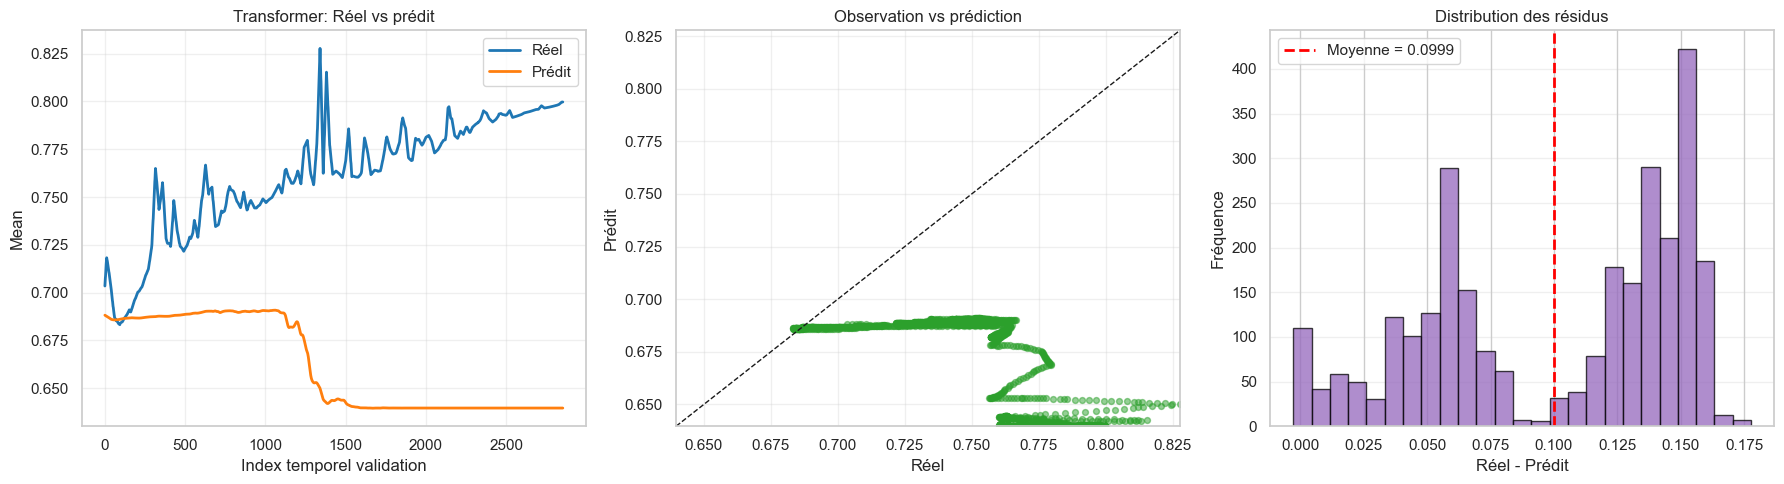

In [13]:
if 'intensity_results_df' not in globals() or intensity_results_df.empty:
    print("⚠ Aucun résultat d'intensité disponible. Exécute d'abord la cellule d'entraînement.")
else:
    best_intensity_model = intensity_results_df.iloc[0]['Model']
    best_intensity_plot = intensity_results_plots[best_intensity_model]
    best_intensity_metrics = intensity_results_df.iloc[0]

    title_text = "VISUALISATION DU MEILLEUR MODÈLE D'INTENSITÉ"
    print(f'{"="*70}')
    print(f'{title_text:^70}')
    print(f'{"="*70}\n')
    print(best_intensity_metrics.to_string())

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Série temporelle réel vs prédit
    ax = axes[0]
    ax.plot(best_intensity_plot['time_idx'], best_intensity_plot['truth_h1'], label='Réel', color='tab:blue', linewidth=2)
    ax.plot(best_intensity_plot['time_idx'], best_intensity_plot['pred_h1'], label='Prédit', color='tab:orange', linewidth=2)
    ax.set_title(f'{best_intensity_model}: Réel vs prédit')
    ax.set_xlabel('Index temporel validation')
    ax.set_ylabel(intensity_target_col)
    ax.legend()
    ax.grid(alpha=0.3)

    # Nuage de points obs vs pred
    ax = axes[1]
    ax.scatter(best_intensity_plot['truth_h1'], best_intensity_plot['pred_h1'], alpha=0.5, s=18, color='tab:green')
    lims = [
        min(best_intensity_plot['truth_h1'].min(), best_intensity_plot['pred_h1'].min()),
        max(best_intensity_plot['truth_h1'].max(), best_intensity_plot['pred_h1'].max()),
    ]
    ax.plot(lims, lims, 'k--', linewidth=1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_title('Observation vs prédiction')
    ax.set_xlabel('Réel')
    ax.set_ylabel('Prédit')
    ax.grid(alpha=0.3)

    # Résidus
    ax = axes[2]
    residuals = best_intensity_plot['truth_h1'] - best_intensity_plot['pred_h1']
    ax.hist(residuals, bins=25, color='tab:purple', alpha=0.75, edgecolor='black')
    ax.axvline(residuals.mean(), color='red', linestyle='--', linewidth=2, label=f'Moyenne = {residuals.mean():.4f}')
    ax.set_title('Distribution des résidus')
    ax.set_xlabel('Réel - Prédit')
    ax.set_ylabel('Fréquence')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()


In [ ]:
from pathlib import Path
import re


def _sanitize_model_name(model_name):
    return re.sub(r'[^A-Za-z0-9_.-]+', '_', str(model_name)).strip('_') or 'model'


def _save_model_weights(models_dict, output_dir, proxy_name):
    if not isinstance(models_dict, dict) or len(models_dict) == 0:
        print(f"Aucun modèle à sauvegarder pour le proxy {proxy_name}.")
        return []

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    saved_paths = []
    for model_name, model in models_dict.items():
        if not hasattr(model, 'state_dict'):
            print(f"Modèle ignoré (pas de state_dict): {model_name}")
            continue

        file_path = output_dir / f"proxy_{_sanitize_model_name(proxy_name)}_{_sanitize_model_name(model_name)}.pth"
        torch.save(
            {
                'model_name': model_name,
                'model_type': type(model).__name__,
                'proxy_name': proxy_name,
                'state_dict': {key: value.detach().cpu() for key, value in model.state_dict().items()},
            },
            file_path,
        )
        saved_paths.append(file_path)

    if saved_paths:
        print(f"{len(saved_paths)} fichier(s) de poids sauvegardé(s) pour le proxy {proxy_name} dans {output_dir}")
        for path in saved_paths:
            print(f"- {path}")
    return saved_paths


weights_root = Path('model_weights')
saved_weight_files = []

if 'trained_models' in globals():
    saved_weight_files += _save_model_weights(trained_models, weights_root / 'frequency', 'frequency')

if 'intensity_trained_models' in globals():
    saved_weight_files += _save_model_weights(intensity_trained_models, weights_root / 'intensity', 'intensity')

if not saved_weight_files:
    print("Aucun dictionnaire de modèles entraînés n'a été trouvé dans l'environnement courant.")